# 스크리닝 데이터로 다음 실험 후보 고르기

## 문제의식

수만 개 화합물 중 어느 것부터 실험할지 정하는 것이 신약 발굴의 첫 단계입니다.
무작위로 100개를 고르면 활성 화합물은 서너 개 나옵니다.

머신러닝 모델을 쓰면 이 숫자를 크게 끌어올릴 수 있다고 알려져 있습니다.
그런데 그 성능이 **새로운 구조를 찾아내는 능력**인지,
**이미 아는 것과 닮은 것을 골라내는 능력**인지는
구분해서 보고되지 않는 경우가 많습니다.

이 노트북은 그 둘을 나눠서 측정합니다.

```
   스크리닝 데이터 41,127개 (활성 3.5%)
        │
        │  일부로 모델 학습
        ▼
   나머지에 대해 활성 확률 예측
        │
        ▼
   확률 높은 순으로 100개 선택
        │
        ▼
   실제 활성 몇 개?  /  무작위로 골랐을 때보다 몇 배?
        │
        ▼
   그 성능은 어디서 나왔나?
```

## 데이터

MoleculeNet의 **HIV 데이터셋** 하나만 사용합니다.

- 출처: NCI Drug Therapeutics Program(DTP)의 AIDS Antiviral Screen
- 4만 개가 넘는 화합물의 HIV 복제 억제 능력을 실제로 시험한 결과
- 화합물 41,127개, 활성 1,443개(3.51%), 비활성 39,684개
- 사용하는 열은 두 개: `smiles`(구조), `HIV_active`(0/1)

## 진행 순서

1번부터 7번 셀에서 모델을 만들고 성능을 측정합니다.
8번부터 11번 셀에서 그 성능이 어디서 나왔는지 파고듭니다.
12번부터 15번 셀에서 천연물과 다른 모델로 범위를 넓힙니다.

## 라이선스

코드는 MIT License. 데이터는 NCI 공개 데이터이며 MoleculeNet을 통해 배포됩니다.

In [2]:
# ==================== 1번 셀 ====================
# 필요한 라이브러리를 불러오고, 설치 상태와 버전을 확인합니다.
# ================================================

import sys
import random

print("=" * 60)
print("환경 확인")
print("=" * 60)
print(f"Python : {sys.version.split()[0]}")

# ------------------------------------------------------------
# 라이브러리를 하나씩 불러옵니다.
# 없는 것이 있으면 어떤 것이 없는지 바로 알 수 있도록
# try-except로 감싸서 확인합니다.
# ------------------------------------------------------------
missing = []          # 설치가 안 된 라이브러리 이름을 모아둘 리스트

try:
    import numpy as np
    print(f"numpy        : {np.__version__}")
except ImportError:
    missing.append("numpy")

try:
    import pandas as pd
    print(f"pandas       : {pd.__version__}")
except ImportError:
    missing.append("pandas")

try:
    import sklearn
    print(f"scikit-learn : {sklearn.__version__}")
except ImportError:
    missing.append("scikit-learn")

try:
    import matplotlib
    import matplotlib.pyplot as plt
    print(f"matplotlib   : {matplotlib.__version__}")
except ImportError:
    missing.append("matplotlib")

try:
    import rdkit
    from rdkit import Chem
    from rdkit import RDLogger
    print(f"rdkit        : {rdkit.__version__}")
except ImportError:
    missing.append("rdkit")


# ------------------------------------------------------------
# 빠진 라이브러리가 있으면 설치 명령을 안내하고 여기서 멈춥니다.
# ------------------------------------------------------------
if missing:
    print()
    print("!" * 60)
    print("설치되지 않은 라이브러리가 있습니다:", ", ".join(missing))
    print()
    print("아래 명령을 실행한 뒤 이 셀을 다시 실행하세요.")
    print(f"  pip install {' '.join(missing)}")
    print("!" * 60)

else:
    # --------------------------------------------------------
    # 여기부터는 모든 라이브러리가 정상일 때만 실행됩니다.
    # --------------------------------------------------------

    # RDKit은 이상한 SMILES를 만나면 경고를 대량으로 출력합니다.
    # 우리는 3번 셀에서 직접 실패 개수를 세어 확인할 것이므로
    # 여기서는 경고 출력을 꺼둡니다.
    RDLogger.DisableLog("rdApp.*")

    # 난수 고정: 매번 같은 결과가 나오도록 합니다.
    # 결과를 남에게 보여주거나 GitHub에 올릴 때 반드시 필요합니다.
    RANDOM_SEED = 42
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # 표 출력 설정: SMILES가 길어서 잘리지 않도록 폭을 넉넉히 잡습니다.
    pd.set_option("display.max_colwidth", 60)
    pd.set_option("display.width", 160)

    # --------------------------------------------------------
    # 그래프 기본 설정
    # --------------------------------------------------------
    plt.rcParams["figure.figsize"] = (8, 5)
    plt.rcParams["figure.dpi"] = 110
    plt.rcParams["axes.grid"] = True
    plt.rcParams["grid.alpha"] = 0.3

    # --------------------------------------------------------
    # 한글 폰트 설정
    #   윈도우 : Malgun Gothic
    #   맥     : AppleGothic
    #   리눅스 : NanumGothic
    # --------------------------------------------------------
    from matplotlib import font_manager

    # 시스템에 설치된 폰트 이름을 모두 모읍니다.
    installed_fonts = {f.name for f in font_manager.fontManager.ttflist}

    # 후보를 앞에서부터 확인해서 있는 것을 씁니다.
    font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "NanumBarunGothic"]

    korean_font = None
    for name in font_candidates:
        if name in installed_fonts:
            korean_font = name
            break

    if korean_font:
        plt.rcParams["font.family"] = korean_font
        # 한글 폰트를 쓰면 마이너스 기호가 깨지므로 이 설정이 필요합니다.
        plt.rcParams["axes.unicode_minus"] = False
        print(f"한글 폰트     : {korean_font}")
    else:
        print("한글 폰트     : 찾지 못함 (그래프 라벨은 영문으로 표시됩니다)")

    # --------------------------------------------------------
    # 프로젝트 전체에서 쓸 설정값을 한곳에 모아둡니다.
    # 나중에 값을 바꿀 때 이 셀만 고치면 됩니다.
    # --------------------------------------------------------
    DATA_URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv"

    TOP_K        = 100    # 상위 몇 개를 "다음에 실험할 후보"로 볼 것인가
    TEST_RATIO   = 0.2    # 검증용으로 떼어놓을 비율
    FP_BITS      = 2048   # 분자 지문의 길이 (4번 셀에서 사용)
    FP_RADIUS    = 2      # 분자 지문의 반경 (2 = ECFP4에 해당)

    print()
    print("=" * 60)
    print("설정 완료")
    print("=" * 60)
    print(f"난수 시드        : {RANDOM_SEED}")
    print(f"상위 K개         : {TOP_K}")
    print(f"검증 비율        : {TEST_RATIO}")
    print(f"지문 길이 / 반경 : {FP_BITS} bits / radius {FP_RADIUS}")

환경 확인
Python : 3.12.10
numpy        : 2.2.6
pandas       : 2.2.3
scikit-learn : 1.9.0
matplotlib   : 3.10.9
rdkit        : 2026.03.6
한글 폰트     : Malgun Gothic

설정 완료
난수 시드        : 42
상위 K개         : 100
검증 비율        : 0.2
지문 길이 / 반경 : 2048 bits / radius 2


In [3]:
# ==================== 2번 셀 ====================
# MoleculeNet HIV 데이터셋을 인터넷에서 직접 읽어옵니다.
# 파일을 따로 저장하지 않고 메모리로 바로 불러옵니다.
# ================================================

print("=" * 60)
print("데이터 내려받기")
print("=" * 60)
print(f"주소: {DATA_URL}")
print("(파일 크기 약 2MB, 몇 초 걸립니다)")
print()

# ------------------------------------------------------------
# 1) 공식 주소에서 먼저 시도합니다.
#    실패하면 HuggingFace 미러로 자동으로 넘어갑니다.
# ------------------------------------------------------------
MIRROR_URL = (
    "https://huggingface.co/datasets/scikit-fingerprints/"
    "MoleculeNet_HIV/resolve/main/HIV.csv"
)

df = None

try:
    df = pd.read_csv(DATA_URL)
    print("[성공] 공식 주소에서 불러왔습니다.")
except Exception as e:
    print(f"[실패] 공식 주소: {type(e).__name__}")
    print("       미러 주소로 다시 시도합니다...")
    try:
        df = pd.read_csv(MIRROR_URL)
        print("[성공] 미러 주소에서 불러왔습니다.")
    except Exception as e2:
        print(f"[실패] 미러 주소: {type(e2).__name__}: {e2}")
        print()
        print("두 주소 모두 실패했습니다. 인터넷 연결을 확인하거나,")
        print("브라우저로 아래 주소에 접속해 HIV.csv를 직접 내려받은 뒤")
        print("df = pd.read_csv('HIV.csv') 로 읽어주세요.")
        print(f"  {DATA_URL}")


# ------------------------------------------------------------
# 2) 제대로 불러왔는지 확인합니다.
# ------------------------------------------------------------
if df is None:
    print("\n데이터를 불러오지 못했습니다. 다음 셀로 넘어가지 마세요.")

else:
    print()
    print("=" * 60)
    print("기본 정보")
    print("=" * 60)
    print(f"행(화합물) 수 : {len(df):,}")
    print(f"열 개수       : {df.shape[1]}")
    print(f"열 이름       : {list(df.columns)}")

    # --------------------------------------------------------
    # 3) 앞부분 몇 줄을 직접 눈으로 확인합니다.
    #    데이터를 받았으면 항상 실제 내용을 봐야 합니다.
    # --------------------------------------------------------
    print()
    print("--- 앞 5줄 ---")
    print(df.head(5).to_string())

    # --------------------------------------------------------
    # 4) 우리가 쓸 두 열이 실제로 있는지 확인합니다.
    #    열 이름이 다르면 여기서 바로 드러납니다.
    # --------------------------------------------------------
    SMILES_COL = "smiles"
    LABEL_COL  = "HIV_active"

    print()
    print("--- 필요한 열 확인 ---")
    for col in [SMILES_COL, LABEL_COL]:
        status = "있음" if col in df.columns else "없음 ← 문제!"
        print(f"  {col:<12} : {status}")

    if SMILES_COL in df.columns and LABEL_COL in df.columns:

        # ----------------------------------------------------
        # 5) 활성 / 비활성 개수를 셉니다.
        #    이 프로젝트의 모든 결과가 이 비율을 기준으로 해석됩니다.
        # ----------------------------------------------------
        n_total    = len(df)
        n_active   = int((df[LABEL_COL] == 1).sum())
        n_inactive = int((df[LABEL_COL] == 0).sum())
        active_pct = n_active / n_total * 100

        print()
        print("=" * 60)
        print("라벨 분포")
        print("=" * 60)
        print(f"  활성   (1) : {n_active:>7,} 개  ({active_pct:5.2f}%)")
        print(f"  비활성 (0) : {n_inactive:>7,} 개  ({100 - active_pct:5.2f}%)")
        print(f"  합계       : {n_total:>7,} 개")

        # ----------------------------------------------------
        # 6) 결측치를 확인합니다.
        # ----------------------------------------------------
        n_na_smiles = int(df[SMILES_COL].isna().sum())
        n_na_label  = int(df[LABEL_COL].isna().sum())
        print()
        print(f"  빈 SMILES  : {n_na_smiles} 개")
        print(f"  빈 라벨    : {n_na_label} 개")

        # ----------------------------------------------------
        # 7) 무작위로 100개를 골랐을 때의 기댓값.
        #    앞으로 나올 모든 모델 성능은 이 값과 비교합니다.
        # ----------------------------------------------------
        random_expected = TOP_K * n_active / n_total

        print()
        print("=" * 60)
        print("기준선 (이 숫자를 기억해 두세요)")
        print("=" * 60)
        print(f"  무작위로 {TOP_K}개를 고르면")
        print(f"  활성이 평균 {random_expected:.1f}개 나옵니다.")
        print()
        print(f"  → 모델이 {TOP_K}개 중 활성 35개를 잡으면")
        print(f"    {35 / random_expected:.1f}배 좋아진 것입니다.")

    else:
        print()
        print("열 이름이 예상과 다릅니다. 위 '열 이름' 출력을 보고")
        print("SMILES_COL, LABEL_COL 값을 맞춰 수정해주세요.")

데이터 내려받기
주소: https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv
(파일 크기 약 2MB, 몇 초 걸립니다)

[성공] 공식 주소에서 불러왔습니다.

기본 정보
행(화합물) 수 : 41,127
열 개수       : 3
열 이름       : ['smiles', 'activity', 'HIV_active']

--- 앞 5줄 ---
                                                                                 smiles activity  HIV_active
0                                  CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2       CI           0
1  C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3)CC(c3ccccc3)=[O+]2)[O+]=C(c2ccccc2)C1       CI           0
2                                                      CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21       CI           0
3                                       Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1       CI           0
4                                                                O=S(=O)(O)CCS(=O)(=O)O       CI           0

--- 필요한 열 확인 ---
  smiles       : 있음
  HIV_active   : 있음

라벨 분포
  활성   (1) :   1,443 개  ( 3.51%)
  비활성 (0) :  39,684 

## 2번 셀 결과 확인

| 항목 | 값 |
|---|---|
| 화합물 수 | 41,127 |
| 활성 | 1,443 (3.51%) |
| 비활성 | 39,684 (96.49%) |
| 결측치 | 없음 |

### 열 구성

- `smiles` — 분자 구조를 한 줄 문자열로 적은 것 (예: `CCO` = 에탄올)
- `activity` — 원본 실험 판정. CI(효과 없음) / CM(효과 어느 정도) / CA(효과 확실)
- `HIV_active` — CI는 0, CM·CA는 1로 묶은 라벨. **우리가 쓸 정답**

### 이 문제의 특징

활성이 3.51%뿐입니다. 전부 "효과 없음"이라고만 답해도 정확도 96.5%가 나오므로
**정확도는 의미가 없습니다.**
보는 것은 "상위 100개 중 활성 몇 개"뿐입니다.

무작위로 100개를 고르면 활성은 평균 **3.5개**.
앞으로 나오는 모든 숫자는 이 값과 비교합니다.

In [4]:
# ==================== 3번 셀 ====================
# SMILES 문자열을 RDKit 분자 객체로 변환합니다.
# 변환에 실패하는 분자가 몇 개인지 반드시 확인합니다.
# ================================================

from rdkit.Chem import Descriptors

print("=" * 60)
print("SMILES → 분자 변환")
print("=" * 60)
print(f"대상: {len(df):,} 개")
print("(30초~1분 정도 걸립니다)")
print()

# ------------------------------------------------------------
# 1) 한 줄씩 돌면서 변환을 시도합니다.
#    성공한 것만 모으고, 실패한 것은 따로 기록합니다.
# ------------------------------------------------------------
mols        = []   # 변환에 성공한 분자 객체
keep_index  = []   # 성공한 행의 원래 위치
failed_rows = []   # 실패한 행의 정보

for i, smi in enumerate(df[SMILES_COL].values):

    # RDKit이 SMILES를 읽어서 분자로 만듭니다.
    # 읽지 못하면 None을 돌려줍니다.
    mol = Chem.MolFromSmiles(smi)

    if mol is None:
        failed_rows.append({"행번호": i, "smiles": smi})
    else:
        mols.append(mol)
        keep_index.append(i)

    # 진행 상황 표시 (1만 개마다)
    if (i + 1) % 10000 == 0:
        print(f"  {i + 1:,} / {len(df):,} 처리 중...")

print()
print("--- 변환 결과 ---")
print(f"  성공 : {len(mols):,} 개")
print(f"  실패 : {len(failed_rows):,} 개")


# ------------------------------------------------------------
# 2) 실패한 것이 있으면 몇 개 보여줍니다.
#    왜 실패했는지 눈으로 확인하는 것이 중요합니다.
# ------------------------------------------------------------
if failed_rows:
    print()
    print("--- 실패한 SMILES 예시 (최대 5개) ---")
    for row in failed_rows[:5]:
        smi_short = row["smiles"][:70]
        print(f"  행 {row['행번호']:>6} : {smi_short}")


# ------------------------------------------------------------
# 3) 성공한 것만 남긴 새 데이터프레임을 만듭니다.
#    원본 df는 그대로 두고 data라는 이름으로 새로 만듭니다.
# ------------------------------------------------------------
data = df.iloc[keep_index].reset_index(drop=True).copy()
data["mol"] = mols

print()
print("=" * 60)
print("정리 후 데이터")
print("=" * 60)
print(f"  화합물 수 : {len(data):,} 개")

n_active_now = int((data[LABEL_COL] == 1).sum())
pct_now      = n_active_now / len(data) * 100
print(f"  활성      : {n_active_now:,} 개 ({pct_now:.2f}%)")
print(f"  비활성    : {len(data) - n_active_now:,} 개")

# 변환 실패로 활성이 몇 개 사라졌는지 확인합니다.
lost_active = n_active - n_active_now
print(f"  변환 실패로 잃은 활성 : {lost_active} 개")


# ------------------------------------------------------------
# 4) 분자 크기를 확인합니다.
#    이 데이터셋에는 일반적인 의약품 크기를 벗어난 것들이 섞여 있어
#    미리 확인해 두면 나중에 결과를 해석할 때 도움이 됩니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("분자량 분포")
print("=" * 60)

mw_list = [Descriptors.MolWt(m) for m in data["mol"]]
data["mol_weight"] = mw_list

mw_series = pd.Series(mw_list)
print(f"  최소   : {mw_series.min():8.1f}")
print(f"  25%    : {mw_series.quantile(0.25):8.1f}")
print(f"  중앙값 : {mw_series.median():8.1f}")
print(f"  75%    : {mw_series.quantile(0.75):8.1f}")
print(f"  최대   : {mw_series.max():8.1f}")

# 일반적인 경구 의약품은 대략 150~500 범위입니다.
n_small = int((mw_series < 150).sum())
n_large = int((mw_series > 900).sum())
print()
print(f"  분자량 150 미만 : {n_small:,} 개 (너무 작음)")
print(f"  분자량 900 초과 : {n_large:,} 개 (너무 큼)")
print()
print("  ※ 지금은 제거하지 않고 그대로 둡니다.")
print("     원본 데이터 그대로 쓰는 것이 비교의 기준이 되기 때문입니다.")


# ------------------------------------------------------------
# 5) 중복 확인
#    같은 분자가 여러 번 들어 있으면 학습/검증에 나뉘어 들어가
#    성능이 부풀려질 수 있습니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("중복 확인")
print("=" * 60)

# RDKit으로 표준화한 SMILES(정규 SMILES)를 만들어 비교합니다.
# 같은 분자를 다르게 쓴 경우를 잡아내기 위해서입니다.
canonical = [Chem.MolToSmiles(m) for m in data["mol"]]
data["canonical_smiles"] = canonical

n_unique = len(set(canonical))
n_dup    = len(canonical) - n_unique

print(f"  고유 분자 수 : {n_unique:,} 개")
print(f"  중복         : {n_dup:,} 개")

if n_dup > 0:
    print()
    print("  ※ 중복이 있습니다. 5번 셀에서 분할하기 전에 처리합니다.")
else:
    print()
    print("  중복 없음.")

SMILES → 분자 변환
대상: 41,127 개
(30초~1분 정도 걸립니다)

  10,000 / 41,127 처리 중...
  20,000 / 41,127 처리 중...
  30,000 / 41,127 처리 중...
  40,000 / 41,127 처리 중...

--- 변환 결과 ---
  성공 : 41,120 개
  실패 : 7 개

--- 실패한 SMILES 예시 (최대 5개) ---
  행    137 : O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3
  행    987 : Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1
  행  12882 : Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C6c7c(cc(O)cc7[OH+]3)OC(c
  행  18293 : CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=CN(C)C(C)=C1[OH+]3)[O+]=
  행  30784 : CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(c1ccccc1)[OH+]2

정리 후 데이터
  화합물 수 : 41,120 개
  활성      : 1,443 개 (3.51%)
  비활성    : 39,677 개
  변환 실패로 잃은 활성 : 0 개

분자량 분포
  최소   :     25.9
  25%    :    267.4
  중앙값 :    333.4
  75%    :    426.9
  최대   :   3411.4

  분자량 150 미만 : 517 개 (너무 작음)
  분자량 900 초과 : 653 개 (너무 큼)

  ※ 지금은 제거하지 않고 그대로 둡니다.
     원본 데이터 그대로 쓰는 것이 비교의 기준이 되기 때문입니다.

중복 확인
  고유 분자 수 : 41,120 개
  중복         : 0 개

  중복 없음.


## 3번 셀 결과 확인

| 항목 | 결과 |
|---|---|
| 변환 성공 | 41,120 (99.98%) |
| 변환 실패 | 7 |
| 잃은 활성 | 0 |
| 중복 분자 | 0 |

### 실패한 7개

실패 목록은 전부 `[Al]`, `[B-2]` 같은 **금속이 포함된 착물**입니다.
RDKit이 이런 구조의 원자가(valence)를 해석하지 못해 변환에 실패했습니다.

전체의 0.02%이고 활성은 하나도 잃지 않았으므로 그대로 제외합니다.

### 분자량 분포

중앙값 333으로, 일반적인 경구 의약품 범위(150~500)에 대부분 들어옵니다.
다만 양 끝이 넓습니다 — 최소 25.9, 최대 3411.4.

| | 개수 |
|---|---|
| 150 미만 | 517 |
| 900 초과 | 653 |

이 데이터는 대규모 스크리닝 결과라 의약품 개발을 염두에 두고 설계된 화합물뿐 아니라
다양한 종류의 물질이 함께 시험되었습니다.

**지금은 제거하지 않습니다.** 원본 그대로 쓰는 것이 비교의 기준이 되고,
나중에 "범위를 벗어난 분자를 빼면 성능이 달라지는가"를 별도로 확인할 수 있기 때문입니다.

### 중복 없음

같은 분자가 학습과 검증에 나뉘어 들어가면 성능이 부풀려지는데,
중복이 0이므로 그 문제는 없습니다.

다만 **완전히 같은 분자**가 없다는 뜻일 뿐,
비슷하게 생긴 분자는 여전히 많습니다. 그게 8~9번 셀에서 다룰 문제입니다.

In [5]:
# ==================== 4번 셀 ====================
# 분자를 머신러닝이 읽을 수 있는 숫자 벡터(지문)로 바꿉니다.
# 결과는 41,120 x 2048 크기의 0/1 행렬이 됩니다.
# ================================================

from rdkit.Chem import rdFingerprintGenerator

print("=" * 60)
print("분자 지문 계산")
print("=" * 60)
print(f"대상     : {len(data):,} 개")
print(f"설정     : 반경 {FP_RADIUS}, {FP_BITS} bits")
print("(1~2분 걸립니다)")
print()

# ------------------------------------------------------------
# 1) 지문 생성기를 만듭니다.
#    최신 RDKit에서 권장하는 방식입니다.
# ------------------------------------------------------------
fp_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=FP_RADIUS,
    fpSize=FP_BITS,
)

# ------------------------------------------------------------
# 2) 분자 하나씩 지문으로 바꿔 쌓습니다.
# ------------------------------------------------------------
fp_list = []

for i, mol in enumerate(data["mol"].values):
    # GetFingerprintAsNumPy()는 0/1 배열을 바로 돌려줍니다.
    fp = fp_generator.GetFingerprintAsNumPy(mol)
    fp_list.append(fp)

    if (i + 1) % 10000 == 0:
        print(f"  {i + 1:,} / {len(data):,} 처리 중...")

# 리스트를 하나의 2차원 배열로 합칩니다.
X = np.array(fp_list, dtype=np.uint8)

# 정답 라벨도 배열로 꺼내둡니다.
y = data[LABEL_COL].values.astype(np.uint8)

print()
print("=" * 60)
print("결과")
print("=" * 60)
print(f"  X (입력) 크기 : {X.shape}   ← (화합물 수, 지문 길이)")
print(f"  y (정답) 크기 : {y.shape}")
print(f"  X 자료형      : {X.dtype}")
print(f"  메모리        : {X.nbytes / 1024 / 1024:.1f} MB")


# ------------------------------------------------------------
# 3) 지문이 제대로 만들어졌는지 확인합니다.
#    전부 0이거나 전부 1이면 무언가 잘못된 것입니다.
# ------------------------------------------------------------
print()
print("--- 지문 내용 확인 ---")

# 분자 하나당 1이 몇 개나 켜져 있는지
bits_per_mol = X.sum(axis=1)
print(f"  분자당 켜진 비트 수")
print(f"    최소   : {bits_per_mol.min()}")
print(f"    중앙값 : {int(np.median(bits_per_mol))}")
print(f"    최대   : {bits_per_mol.max()}")

# 전체 2048칸 중 한 번도 안 쓰인 칸이 있는지
never_used = int((X.sum(axis=0) == 0).sum())
print(f"  한 번도 사용되지 않은 비트 : {never_used} / {FP_BITS}")

# 문제가 될 만한 경우를 미리 걸러냅니다.
n_empty = int((bits_per_mol == 0).sum())
if n_empty > 0:
    print(f"  ※ 주의: 지문이 전부 0인 분자가 {n_empty}개 있습니다.")
else:
    print(f"  모든 분자가 정상적으로 지문을 가졌습니다.")


# ------------------------------------------------------------
# 4) 실제 지문 한 개를 눈으로 봅니다.
#    앞 40칸만 잘라서 보여줍니다.
# ------------------------------------------------------------
print()
print("--- 첫 번째 분자의 지문 (앞 40칸) ---")
print(f"  SMILES : {data[SMILES_COL].iloc[0][:60]}")
print(f"  지문   : {X[0][:40]}")
print(f"  (총 {FP_BITS}칸 중 {X[0].sum()}칸이 1)")


# ------------------------------------------------------------
# 5) 활성/비활성 그룹의 지문이 실제로 다른지 간단히 확인합니다.
#    차이가 전혀 없다면 학습이 불가능하다는 뜻입니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("활성 / 비활성 그룹 비교")
print("=" * 60)

active_bits   = X[y == 1].sum(axis=1)
inactive_bits = X[y == 0].sum(axis=1)

print(f"  활성   분자당 켜진 비트 평균 : {active_bits.mean():.1f}")
print(f"  비활성 분자당 켜진 비트 평균 : {inactive_bits.mean():.1f}")

# 각 비트가 활성 그룹에서 켜질 확률과 비활성 그룹에서 켜질 확률의 차이
p_active   = X[y == 1].mean(axis=0)
p_inactive = X[y == 0].mean(axis=0)
diff       = np.abs(p_active - p_inactive)

print()
print(f"  두 그룹 간 비트별 출현율 차이")
print(f"    최대   : {diff.max():.3f}")
print(f"    상위 10개 평균 : {np.sort(diff)[-10:].mean():.3f}")
print()
if diff.max() > 0.05:
    print("  → 두 그룹의 지문에 뚜렷한 차이가 있습니다. 학습 가능합니다.")
else:
    print("  → 차이가 작습니다. 학습이 어려울 수 있습니다.")

분자 지문 계산
대상     : 41,120 개
설정     : 반경 2, 2048 bits
(1~2분 걸립니다)

  10,000 / 41,120 처리 중...
  20,000 / 41,120 처리 중...
  30,000 / 41,120 처리 중...
  40,000 / 41,120 처리 중...

결과
  X (입력) 크기 : (41120, 2048)   ← (화합물 수, 지문 길이)
  y (정답) 크기 : (41120,)
  X 자료형      : uint8
  메모리        : 80.3 MB

--- 지문 내용 확인 ---
  분자당 켜진 비트 수
    최소   : 3
    중앙값 : 38
    최대   : 154
  한 번도 사용되지 않은 비트 : 0 / 2048
  모든 분자가 정상적으로 지문을 가졌습니다.

--- 첫 번째 분자의 지문 (앞 40칸) ---
  SMILES : CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)=[O+]2
  지문   : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0]
  (총 2048칸 중 17칸이 1)

활성 / 비활성 그룹 비교
  활성   분자당 켜진 비트 평균 : 45.9
  비활성 분자당 켜진 비트 평균 : 39.1

  두 그룹 간 비트별 출현율 차이
    최대   : 0.158
    상위 10개 평균 : 0.127

  → 두 그룹의 지문에 뚜렷한 차이가 있습니다. 학습 가능합니다.


## 4번 셀 결과 확인

분자 41,120개가 각각 2048칸짜리 0/1 벡터로 바뀌었습니다.
이제 모델에 넣을 수 있는 형태입니다.

### 지문이 정상인가

분자 하나당 켜진 칸(1)은 평균 40개 정도입니다.
2048칸 중 40칸만 켜져 있으니 **대부분 0인 벡터**인데, 지문은 원래 이렇습니다.
분자 하나에 들어 있는 부분 구조의 종류가 그 정도이기 때문입니다.

비어 있는 분자(전부 0)는 없었고, 2048칸이 모두 한 번 이상 쓰였습니다.
설정이 적절했다는 뜻입니다.

### 활성과 비활성이 구분되는가

| | 분자당 켜진 칸 수 |
|---|---|
| 활성 | 45.9 |
| 비활성 | 39.1 |

활성 화합물이 평균적으로 구조가 더 복잡합니다.

더 중요한 건 **칸별 비교**입니다.
특정 부분 구조는 활성 그룹에서 16%p 더 자주 나타났습니다.
즉 "이 구조가 있으면 활성일 가능성이 높다"는 신호가 실제로 존재합니다.

**모델이 학습할 재료가 있다는 확인입니다.** 없었다면 여기서 멈춰야 했습니다.

### 다만

차이가 있다고 해서 새로운 화합물을 찾아낼 수 있다는 뜻은 아닙니다.
활성 화합물들끼리 비슷하게 생겨서 생긴 차이일 수도 있고,
그렇다면 모델은 아는 것만 다시 찾아냅니다.

이걸 확인하는 것이 8~9번 셀입니다.

In [6]:
# ==================== 5번 셀 ====================
# 데이터를 학습용과 검증용으로 나눕니다.
# 먼저 가장 흔히 쓰는 "무작위 분할"부터 합니다.
# 8번 셀에서 "스캐폴드 분할"과 비교할 예정입니다.
# ================================================

from sklearn.model_selection import train_test_split

print("=" * 60)
print("무작위 분할")
print("=" * 60)

# ------------------------------------------------------------
# 1) 전체 인덱스를 학습용/검증용으로 나눕니다.
#
#    stratify=y 를 주면 활성 비율이 양쪽에 똑같이 유지됩니다.
#    활성이 3.5%뿐이라 이걸 안 하면 검증 세트에
#    활성이 우연히 너무 적게 들어갈 수 있습니다.
# ------------------------------------------------------------
all_index = np.arange(len(data))

train_idx_random, test_idx_random = train_test_split(
    all_index,
    test_size=TEST_RATIO,
    stratify=y,               # 활성 비율 유지
    random_state=RANDOM_SEED, # 항상 같은 결과가 나오도록
)

# ------------------------------------------------------------
# 2) 나눈 결과를 실제 데이터에 적용합니다.
# ------------------------------------------------------------
X_train_random = X[train_idx_random]
y_train_random = y[train_idx_random]
X_test_random  = X[test_idx_random]
y_test_random  = y[test_idx_random]

# ------------------------------------------------------------
# 3) 제대로 나뉘었는지 확인합니다.
# ------------------------------------------------------------
print()
print("--- 분할 결과 ---")
print(f"{'':12} {'전체':>8} {'활성':>8} {'활성비율':>10}")
print("-" * 42)

for name, y_part in [
    ("학습용", y_train_random),
    ("검증용", y_test_random),
]:
    n     = len(y_part)
    n_act = int(y_part.sum())
    pct   = n_act / n * 100
    print(f"{name:12} {n:>8,} {n_act:>8,} {pct:>9.2f}%")

print("-" * 42)
print(f"{'합계':12} {len(y):>8,} {int(y.sum()):>8,} {y.mean() * 100:>9.2f}%")


# ------------------------------------------------------------
# 4) 학습용과 검증용이 겹치지 않는지 확인합니다.
#    겹치면 성능이 완전히 잘못 나옵니다.
# ------------------------------------------------------------
overlap = set(train_idx_random) & set(test_idx_random)
print()
print(f"  학습/검증 겹침 : {len(overlap)} 개")
if len(overlap) == 0:
    print("  → 정상입니다.")
else:
    print("  → 문제가 있습니다. 코드를 확인하세요.")


# ------------------------------------------------------------
# 5) 이 분할에서의 기준선을 계산합니다.
#
#    검증 세트에서 무작위로 TOP_K개를 골랐을 때
#    활성이 몇 개 나올지가 앞으로의 비교 기준입니다.
# ------------------------------------------------------------
baseline_random = TOP_K * y_test_random.mean()

print()
print("=" * 60)
print("이 분할에서의 기준선")
print("=" * 60)
print(f"  검증 세트 크기   : {len(y_test_random):,} 개")
print(f"  검증 세트 활성   : {int(y_test_random.sum()):,} 개")
print(f"  무작위 {TOP_K}개 선택 시 기대 활성 : {baseline_random:.1f} 개")


# ------------------------------------------------------------
# 6) 나중에 쓸 수 있도록 결과를 정리해 둡니다.
#    분할 방식별로 결과를 모을 딕셔너리를 만듭니다.
# ------------------------------------------------------------
results = {}   # 앞으로 모든 실험 결과를 여기에 모읍니다

splits = {
    "random": {
        "train_idx": train_idx_random,
        "test_idx":  test_idx_random,
        "baseline":  baseline_random,
    }
}

print()
print(f"  분할 정보를 splits['random'] 에 저장했습니다.")

무작위 분할

--- 분할 결과 ---
                   전체       활성       활성비율
------------------------------------------
학습용            32,896    1,154      3.51%
검증용             8,224      289      3.51%
------------------------------------------
합계             41,120    1,443      3.51%

  학습/검증 겹침 : 0 개
  → 정상입니다.

이 분할에서의 기준선
  검증 세트 크기   : 8,224 개
  검증 세트 활성   : 289 개
  무작위 100개 선택 시 기대 활성 : 3.5 개

  분할 정보를 splits['random'] 에 저장했습니다.


## 5번 셀 결과 확인

| | 화합물 | 활성 | 활성 비율 |
|---|---|---|---|
| 학습용 | 32,896 | 1,154 | 3.51% |
| 검증용 | 8,224 | 289 | 3.51% |

양쪽 활성 비율이 3.51%로 같습니다.
활성이 워낙 적어서 그냥 나누면 한쪽에 몰릴 수 있는데,
비율을 맞춰 나누는 옵션(`stratify`)을 써서 막았습니다.

학습용과 검증용이 겹치는 화합물은 0개입니다.
겹치면 모델이 이미 본 답을 다시 맞히는 셈이라 성능이 무의미해집니다.

### 이번 분할의 기준선

검증 세트 8,224개 중 활성은 289개입니다.
여기서 **아무렇게나 100개를 고르면 활성은 평균 3.5개**입니다.

6번 셀에서 학습할 모델이 이 숫자를 얼마나 끌어올리는지가 첫 번째 결과입니다.

### 이 분할의 한계

무작위로 나눴기 때문에, 비슷하게 생긴 화합물이 학습용과 검증용에
나뉘어 들어갔을 가능성이 높습니다.

그러면 모델은 학습용에서 본 화합물과 닮은 것을 검증용에서 고르기만 해도 맞힙니다.
실제 신약 발굴에서 필요한 건 **처음 보는 골격의 화합물을 찾아내는 능력**인데,
이 분할로는 그 능력을 잴 수 없습니다.

그래서 8번 셀에서 골격이 겹치지 않게 나눈 뒤 다시 측정합니다.
지금 나올 숫자는 **부풀려진 값일 수 있습니다.**

In [7]:
# ==================== 6번 셀 ====================
# 첫 번째 모델: 랜덤 포레스트
# 여러 개의 결정 트리를 만들어 다수결로 예측하는 방식입니다.
# 분자 지문 같은 0/1 데이터에 잘 맞고, 설정할 것이 적어
# 기준선 모델로 널리 쓰입니다.
# ================================================

from sklearn.ensemble import RandomForestClassifier
import time

print("=" * 60)
print("랜덤 포레스트 학습 (무작위 분할)")
print("=" * 60)

# ------------------------------------------------------------
# 1) 모델을 만듭니다.
#
#    n_estimators   : 트리를 몇 개 만들 것인가
#    class_weight   : 활성이 3.5%뿐이라 그냥 두면 모델이
#                     전부 "비활성"이라고 답해버립니다.
#                     'balanced'를 주면 적은 쪽에 가중치를 줘서
#                     활성도 제대로 보게 만듭니다.
#    n_jobs=-1      : CPU 코어를 전부 사용 (속도)
# ------------------------------------------------------------
model_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

print(f"  트리 개수   : 300")
print(f"  클래스 가중 : balanced")
print()
print("  학습 중... (1~3분)")

t0 = time.time()
model_rf.fit(X_train_random, y_train_random)
elapsed = time.time() - t0

print(f"  완료 ({elapsed:.1f}초)")


# ------------------------------------------------------------
# 2) 검증 세트에 대해 활성 확률을 예측합니다.
#
#    predict()는 0 또는 1만 돌려주지만,
#    우리는 "순위"가 필요하므로 확률을 받습니다.
#    predict_proba()의 두 번째 열이 활성일 확률입니다.
# ------------------------------------------------------------
prob_rf = model_rf.predict_proba(X_test_random)[:, 1]

print()
print("--- 예측 확률 분포 ---")
print(f"  최소   : {prob_rf.min():.4f}")
print(f"  중앙값 : {np.median(prob_rf):.4f}")
print(f"  최대   : {prob_rf.max():.4f}")


# ------------------------------------------------------------
# 3) 앞으로 반복해서 쓸 평가 함수를 만들어 둡니다.
#
#    확률이 높은 순으로 정렬해서 상위 K개를 고르고,
#    그 안에 진짜 활성이 몇 개인지 셉니다.
# ------------------------------------------------------------
def evaluate_topk(y_true, y_prob, k=TOP_K):
    """
    확률 높은 순으로 상위 k개를 골라 활성 개수를 셉니다.

    y_true : 실제 정답 (0/1 배열)
    y_prob : 모델이 예측한 활성 확률
    k      : 상위 몇 개를 볼 것인가

    반환값 : (상위 k개 중 활성 수, 무작위 기대값, 배수)
    """
    # 확률이 큰 순서대로 위치를 정렬합니다.
    # argsort는 작은 순이므로 [::-1]로 뒤집습니다.
    order = np.argsort(y_prob)[::-1]
    top_k_idx = order[:k]

    n_hit     = int(y_true[top_k_idx].sum())   # 상위 k개 중 실제 활성
    n_random  = k * y_true.mean()              # 무작위로 골랐을 때 기대값
    fold      = n_hit / n_random if n_random > 0 else 0

    return n_hit, n_random, fold


# ------------------------------------------------------------
# 4) 평가합니다.
# ------------------------------------------------------------
n_hit, n_random, fold = evaluate_topk(y_test_random, prob_rf)

print()
print("=" * 60)
print(f"결과 — 상위 {TOP_K}개")
print("=" * 60)
print(f"  모델이 찾은 활성   : {n_hit} 개")
print(f"  무작위 기대값      : {n_random:.1f} 개")
print(f"  배수               : {fold:.1f}배")
print()
print(f"  → 실험 {TOP_K}번으로 활성 {n_hit}개를 찾았습니다.")
print(f"    아무렇게나 골랐다면 {n_random:.1f}개였을 것입니다.")


# ------------------------------------------------------------
# 5) 상위 개수를 바꿔가며 확인합니다.
#    100개에서만 잘 나온 것인지, 전반적으로 잘하는 것인지 봅니다.
# ------------------------------------------------------------
print()
print("--- 상위 개수별 ---")
print(f"{'상위':>8} {'활성':>8} {'무작위':>10} {'배수':>8}")
print("-" * 38)

for k in [50, 100, 200, 500, 1000]:
    h, r, f = evaluate_topk(y_test_random, prob_rf, k=k)
    print(f"{k:>8} {h:>8} {r:>10.1f} {f:>7.1f}배")


# ------------------------------------------------------------
# 6) 결과를 저장해 둡니다. 나중에 다른 모델과 비교합니다.
# ------------------------------------------------------------
results["RF_random"] = {
    "model":  "랜덤 포레스트",
    "split":  "무작위",
    "n_hit":  n_hit,
    "n_rand": n_random,
    "fold":   fold,
    "prob":   prob_rf,
}

print()
print(f"  결과를 results['RF_random'] 에 저장했습니다.")

랜덤 포레스트 학습 (무작위 분할)
  트리 개수   : 300
  클래스 가중 : balanced

  학습 중... (1~3분)
  완료 (68.7초)

--- 예측 확률 분포 ---
  최소   : 0.0000
  중앙값 : 0.0300
  최대   : 1.0000

결과 — 상위 100개
  모델이 찾은 활성   : 70 개
  무작위 기대값      : 3.5 개
  배수               : 19.9배

  → 실험 100번으로 활성 70개를 찾았습니다.
    아무렇게나 골랐다면 3.5개였을 것입니다.

--- 상위 개수별 ---
      상위       활성        무작위       배수
--------------------------------------
      50       41        1.8    23.3배
     100       70        3.5    19.9배
     200      116        7.0    16.5배
     500      173       17.6     9.8배
    1000      195       35.1     5.5배

  결과를 results['RF_random'] 에 저장했습니다.


## 6번 셀 결과 확인

### 상위 100개

| | 활성 개수 |
|---|---|
| 랜덤 포레스트 | **70** |
| 무작위 선택 | 3.5 |

실험 100번으로 활성 70개. 아무렇게나 골랐다면 3~4개입니다. **약 20배.**

### 상위 개수를 늘리면

| 상위 | 활성 | 배수 |
|---|---|---|
| 50 | 41 | 23.3배 |
| 100 | 70 | 19.9배 |
| 500 | 173 | 9.8배 |
| 1000 | 195 | 5.5배 |

뒤로 갈수록 배수가 떨어집니다. 모델이 확신하는 것부터 앞에 놓았으니 당연한 결과입니다.

검증 세트 8,224개 중 상위 1,000개(12%)만 봐도 전체 활성 289개 중 195개를 건졌습니다.

### 이 숫자를 그대로 믿으면 안 되는 이유

무작위로 나눈 데이터라, 학습용과 닮은 화합물이 검증용에 섞여 있을 수 있습니다.
그렇다면 모델은 **새 구조를 찾은 게 아니라 본 것을 다시 찾은 것**입니다.

8~9번 셀에서 골격이 겹치지 않게 다시 나눈 뒤,
이 19.9배가 얼마나 남는지 확인합니다.

In [8]:
# ==================== 7번 셀 ====================
# 모델이 어떤 부분 구조를 보고 활성이라고 판단했는지 확인합니다.
# 블랙박스로 두지 않고 한 번 들여다보는 단계입니다.
# ================================================

from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

print("=" * 60)
print("모델이 중요하게 본 부분 구조")
print("=" * 60)

# ------------------------------------------------------------
# 1) 랜덤 포레스트는 각 입력(비트)이 얼마나 중요했는지 알려줍니다.
# ------------------------------------------------------------
importances = model_rf.feature_importances_

# 중요도가 높은 순으로 상위 10개 비트를 찾습니다.
top_bits = np.argsort(importances)[::-1][:10]

print()
print(f"{'순위':>4} {'비트번호':>8} {'중요도':>10} {'활성출현율':>12} {'비활성출현율':>14}")
print("-" * 54)

for rank, bit in enumerate(top_bits, 1):
    imp     = importances[bit]
    p_act   = X[y == 1][:, bit].mean()   # 활성 그룹에서 이 비트가 켜진 비율
    p_inact = X[y == 0][:, bit].mean()   # 비활성 그룹에서 켜진 비율
    print(f"{rank:>4} {bit:>8} {imp:>10.5f} {p_act:>11.3f} {p_inact:>13.3f}")


# ------------------------------------------------------------
# 2) 가장 중요한 비트가 활성과 비활성에서 얼마나 다른지 봅니다.
# ------------------------------------------------------------
best_bit = top_bits[0]
p_act    = X[y == 1][:, best_bit].mean()
p_inact  = X[y == 0][:, best_bit].mean()

print()
print("--- 1위 비트 해석 ---")
print(f"  비트 {best_bit}번은")
print(f"    활성   화합물의 {p_act * 100:.1f}%")
print(f"    비활성 화합물의 {p_inact * 100:.1f}% 에서 나타납니다.")

if p_act > p_inact:
    print(f"  → 이 구조가 있으면 활성일 가능성이 높습니다.")
else:
    print(f"  → 이 구조가 있으면 비활성일 가능성이 높습니다.")


# ------------------------------------------------------------
# 3) 그 비트가 실제로 어떤 부분 구조인지 찾아봅니다.
#
#    비트 하나는 여러 분자에서 나올 수 있으므로,
#    그 비트를 가진 활성 화합물 중 하나를 골라 확인합니다.
# ------------------------------------------------------------
print()
print("--- 이 비트를 가진 활성 화합물 예시 ---")

# 해당 비트가 켜져 있으면서 활성인 분자들의 위치
has_bit = (X[:, best_bit] == 1) & (y == 1)
example_idx = np.where(has_bit)[0][:3]

for idx in example_idx:
    smi = data[SMILES_COL].iloc[idx]
    print(f"  {smi[:70]}")

print()
print(f"  (총 {int(has_bit.sum())}개의 활성 화합물이 이 구조를 가집니다)")


# ------------------------------------------------------------
# 4) 중요도가 얼마나 몰려 있는지 확인합니다.
#
#    소수의 비트에 몰려 있다면 특정 구조만 보고 판단한다는 뜻이고,
#    골고루 퍼져 있다면 여러 정보를 종합한다는 뜻입니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("중요도 분포")
print("=" * 60)

sorted_imp = np.sort(importances)[::-1]
cum = np.cumsum(sorted_imp)

for n in [10, 50, 100, 500]:
    print(f"  상위 {n:>4}개 비트가 전체 중요도의 {cum[n-1] * 100:>5.1f}% 차지")

n_used = int((importances > 0).sum())
print()
print(f"  실제로 사용된 비트 : {n_used} / {FP_BITS}")

모델이 중요하게 본 부분 구조

  순위     비트번호        중요도        활성출현율         비활성출현율
------------------------------------------------------
   1     1991    0.00817       0.181         0.058
   2      350    0.00775       0.243         0.085
   3      626    0.00658       0.125         0.011
   4      392    0.00650       0.200         0.056
   5     1807    0.00600       0.057         0.012
   6      592    0.00595       0.152         0.038
   7      836    0.00583       0.110         0.014
   8      875    0.00552       0.461         0.313
   9      443    0.00532       0.096         0.013
  10     1476    0.00470       0.251         0.113

--- 1위 비트 해석 ---
  비트 1991번은
    활성   화합물의 18.1%
    비활성 화합물의 5.8% 에서 나타납니다.
  → 이 구조가 있으면 활성일 가능성이 높습니다.

--- 이 비트를 가진 활성 화합물 예시 ---
  NNC(=O)c1ccccc1SSc1ccccc1C(=O)NN
  O=C(NN=Cc1ccc(Cl)cc1Cl)c1ccccc1SSc1ccccc1C(=O)NN=Cc1ccc(Cl)cc1Cl
  Cc1c(N=Nc2cc(N=Nc3ccc(N=Nc4ccc(O)c(C(=O)O)c4)cc3)c(N)cc2N)cccc1S(=O)(=

  (총 261개의 활성 화합물이 이 구조를 가집니다)

중요도 분포
  상위   10개 비트가

## 7번 셀 결과 확인

### 모델이 본 신호

상위 10개 비트는 모두 활성에서 더 자주 나타나는 구조였습니다.

| 비트 | 활성에서 | 비활성에서 |
|---|---|---|
| 1991 | 18.1% | 5.8% |
| 626 | 12.5% | 1.1% |

활성 쪽에서 3~11배 자주 나타납니다. 모델이 볼 신호가 실제로 있었습니다.

### 주의할 점

1991번 비트를 가진 활성 화합물을 꺼내보니,
앞의 두 개가 **같은 골격에 치환기만 다른 유사체**였습니다.

무작위로 나누면 이런 유사체가 학습용과 검증용에 갈라집니다.
그러면 모델은 학습용에서 본 것을 검증용에서 다시 찾기만 해도 맞힙니다.
8~9번 셀에서 다룰 문제입니다.

### 판단이 쏠려 있지는 않은가

상위 10개 비트를 합쳐도 전체 중요도의 6.2%뿐이고, 2048개가 전부 쓰였습니다.
여러 신호를 골고루 보고 판단한다는 뜻입니다.

모델은 정상입니다. 문제는 **평가 방식**입니다.

In [9]:
# ==================== 8번 셀 ====================
# 이번에는 분자 골격(scaffold)이 겹치지 않게 나눕니다.
#
# 골격이란 분자에서 곁가지를 떼어낸 뼈대 부분입니다.
# 같은 골격을 가진 화합물들을 통째로 한쪽에만 보내면,
# 검증 세트에는 학습 때 본 적 없는 골격만 남습니다.
# ================================================

from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict

print("=" * 60)
print("스캐폴드 분할")
print("=" * 60)
print("골격 추출 중... (1~2분)")

# ------------------------------------------------------------
# 1) 분자마다 골격을 뽑아냅니다.
#
#    MurckoScaffold는 고리 구조와 그것을 잇는 부분만 남기고
#    바깥쪽 곁가지를 떼어냅니다.
# ------------------------------------------------------------
scaffolds = []

for mol in data["mol"].values:
    try:
        # includeChirality=False : 입체 정보는 무시 (뼈대만 비교)
        scaf = MurckoScaffold.MurckoScaffoldSmiles(
            mol=mol, includeChirality=False
        )
    except Exception:
        scaf = ""   # 추출 실패 시 빈 문자열
    scaffolds.append(scaf)

data["scaffold"] = scaffolds

# ------------------------------------------------------------
# 2) 골격별로 분자들을 묶습니다.
# ------------------------------------------------------------
scaffold_groups = defaultdict(list)
for i, scaf in enumerate(scaffolds):
    scaffold_groups[scaf].append(i)

print(f"  완료")
print()
print("--- 골격 통계 ---")
print(f"  고유 골격 수     : {len(scaffold_groups):,} 개")
print(f"  분자 수          : {len(data):,} 개")
print(f"  골격당 평균 분자 : {len(data) / len(scaffold_groups):.1f} 개")

# 골격이 비어 있는 경우 (고리가 없는 사슬형 분자)
n_empty_scaf = len(scaffold_groups.get("", []))
print(f"  골격이 없는 분자 : {n_empty_scaf:,} 개 (고리가 없는 구조)")

# 가장 흔한 골격 몇 개
group_sizes = sorted(
    [(len(v), k) for k, v in scaffold_groups.items()], reverse=True
)
print()
print("--- 가장 많은 분자를 가진 골격 ---")
for size, scaf in group_sizes[:5]:
    label = scaf if scaf else "(골격 없음)"
    print(f"  {size:>5}개 : {label[:55]}")


# ------------------------------------------------------------
# 3) 골격 그룹을 크기 순으로 학습용에 먼저 채웁니다.
#
#    큰 그룹부터 학습용에 넣고, 학습용이 목표 크기를 채우면
#    나머지를 검증용으로 보냅니다.
#    이렇게 하면 검증용에는 드물고 새로운 골격이 모입니다.
# ------------------------------------------------------------
target_train_size = int(len(data) * (1 - TEST_RATIO))

train_idx_scaffold = []
test_idx_scaffold  = []

# 큰 그룹부터 순서대로
for size, scaf in group_sizes:
    group = scaffold_groups[scaf]

    if len(train_idx_scaffold) + len(group) <= target_train_size:
        train_idx_scaffold.extend(group)
    else:
        test_idx_scaffold.extend(group)

train_idx_scaffold = np.array(sorted(train_idx_scaffold))
test_idx_scaffold  = np.array(sorted(test_idx_scaffold))


# ------------------------------------------------------------
# 4) 나눈 결과를 확인합니다.
# ------------------------------------------------------------
y_train_scaffold = y[train_idx_scaffold]
y_test_scaffold  = y[test_idx_scaffold]

print()
print("=" * 60)
print("분할 결과 비교")
print("=" * 60)
print(f"{'':16} {'전체':>8} {'활성':>8} {'활성비율':>10}")
print("-" * 46)
print(f"{'[무작위] 학습':16} {len(y_train_random):>8,} "
      f"{int(y_train_random.sum()):>8,} {y_train_random.mean()*100:>9.2f}%")
print(f"{'[무작위] 검증':16} {len(y_test_random):>8,} "
      f"{int(y_test_random.sum()):>8,} {y_test_random.mean()*100:>9.2f}%")
print("-" * 46)
print(f"{'[골격] 학습':16} {len(y_train_scaffold):>8,} "
      f"{int(y_train_scaffold.sum()):>8,} {y_train_scaffold.mean()*100:>9.2f}%")
print(f"{'[골격] 검증':16} {len(y_test_scaffold):>8,} "
      f"{int(y_test_scaffold.sum()):>8,} {y_test_scaffold.mean()*100:>9.2f}%")


# ------------------------------------------------------------
# 5) 두 분할 방식이 실제로 다른지 확인합니다.
#    골격이 겹치지 않는지 세어봅니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("학습/검증 골격 겹침 확인")
print("=" * 60)

for name, tr_idx, te_idx in [
    ("무작위 분할", train_idx_random, test_idx_random),
    ("골격 분할",   train_idx_scaffold, test_idx_scaffold),
]:
    scaf_train = set(data["scaffold"].iloc[tr_idx])
    scaf_test  = set(data["scaffold"].iloc[te_idx])
    shared     = scaf_train & scaf_test

    # 검증 세트 분자 중 학습에 없던 골격을 가진 비율
    te_scafs = data["scaffold"].iloc[te_idx].values
    n_novel  = sum(1 for s in te_scafs if s not in scaf_train)
    pct      = n_novel / len(te_scafs) * 100

    print(f"  [{name}]")
    print(f"    공유 골격 수            : {len(shared):,}")
    print(f"    검증 세트 중 새 골격    : {n_novel:,} / {len(te_scafs):,} ({pct:.1f}%)")
    print()


# ------------------------------------------------------------
# 6) 이 분할의 기준선과 저장
# ------------------------------------------------------------
baseline_scaffold = TOP_K * y_test_scaffold.mean()

splits["scaffold"] = {
    "train_idx": train_idx_scaffold,
    "test_idx":  test_idx_scaffold,
    "baseline":  baseline_scaffold,
}

print("=" * 60)
print("골격 분할에서의 기준선")
print("=" * 60)
print(f"  검증 세트 크기 : {len(y_test_scaffold):,} 개")
print(f"  검증 세트 활성 : {int(y_test_scaffold.sum()):,} 개")
print(f"  무작위 {TOP_K}개 선택 시 기대 활성 : {baseline_scaffold:.1f} 개")

스캐폴드 분할
골격 추출 중... (1~2분)
  완료

--- 골격 통계 ---
  고유 골격 수     : 19,082 개
  분자 수          : 41,120 개
  골격당 평균 분자 : 2.2 개
  골격이 없는 분자 : 1,582 개 (고리가 없는 구조)

--- 가장 많은 분자를 가진 골격 ---
   2090개 : c1ccccc1
   1582개 : (골격 없음)
    165개 : c1ccncc1
    162개 : O=c1ccn(C2CCCO2)c(=O)[nH]1
    162개 : C(=Cc1ccccc1)c1ccccc1

분할 결과 비교
                       전체       활성       활성비율
----------------------------------------------
[무작위] 학습           32,896    1,154      3.51%
[무작위] 검증            8,224      289      3.51%
----------------------------------------------
[골격] 학습            32,896    1,161      3.53%
[골격] 검증             8,224      282      3.43%

학습/검증 골격 겹침 확인
  [무작위 분할]
    공유 골격 수            : 2,357
    검증 세트 중 새 골격    : 3,024 / 8,224 (36.8%)

  [골격 분할]
    공유 골격 수            : 0
    검증 세트 중 새 골격    : 8,224 / 8,224 (100.0%)

골격 분할에서의 기준선
  검증 세트 크기 : 8,224 개
  검증 세트 활성 : 282 개
  무작위 100개 선택 시 기대 활성 : 3.4 개


## 8번 셀 결과 확인

### 골격 통계

41,120개 분자에서 **19,082개의 고유 골격**이 나왔습니다. 골격당 평균 2.2개입니다.

가장 흔한 골격은 벤젠 고리 하나(`c1ccccc1`)로 2,090개.
고리가 아예 없는 사슬형 분자도 1,582개 있어 한 덩어리로 묶였습니다.

### 두 분할의 결정적 차이

| | 학습·검증이 공유하는 골격 | 검증 세트 중 처음 보는 골격 |
|---|---|---|
| 무작위 분할 | 2,357개 | 36.8% |
| 골격 분할 | **0개** | **100%** |

무작위 분할에서는 검증 세트의 **63%가 학습 때 이미 본 골격**이었습니다.
모델이 19.9배를 낸 데에는 이 부분이 크게 기여했을 가능성이 높습니다.

골격 분할에서는 검증 세트 전체가 처음 보는 골격입니다.
실제 신약 발굴에서 마주하는 상황에 훨씬 가깝습니다.

### 활성 비율은 비슷하게 유지됨

골격 분할은 비율을 맞추는 옵션을 쓸 수 없는데도
검증 세트 활성이 282개(3.43%)로 무작위 분할(289개, 3.51%)과 거의 같습니다.
두 결과를 나란히 비교해도 무리가 없습니다.

### 다음

같은 모델을 골격 분할로 다시 학습시킵니다.
**19.9배가 얼마나 남는지**가 이 프로젝트의 핵심 결과입니다.

랜덤 포레스트 학습 (골격 분할)
  학습용 : 32,896 개
  검증용 : 8,224 개

  학습 중... (1~3분)
  완료 (34.9초)

핵심 결과 — 상위 100개 비교
분할 방식                활성        무작위         배수
----------------------------------------------
무작위 분할               70        3.5      19.9배
골격 분할                71        3.4      20.7배
----------------------------------------------
차이                   -1                 -0.8배

  → 골격을 분리하자 활성 발견이 -1% 줄었습니다.

--- 상위 개수별 비교 ---
      상위        무작위분할         골격분할        감소율
----------------------------------------------
      50      41(23.3배)      36(21.0배)        12%
     100      70(19.9배)      71(20.7배)        -1%
     200     116(16.5배)     111(16.2배)         4%
     500     173( 9.8배)     146( 8.5배)        16%
    1000     195( 5.5배)     167( 4.9배)        14%


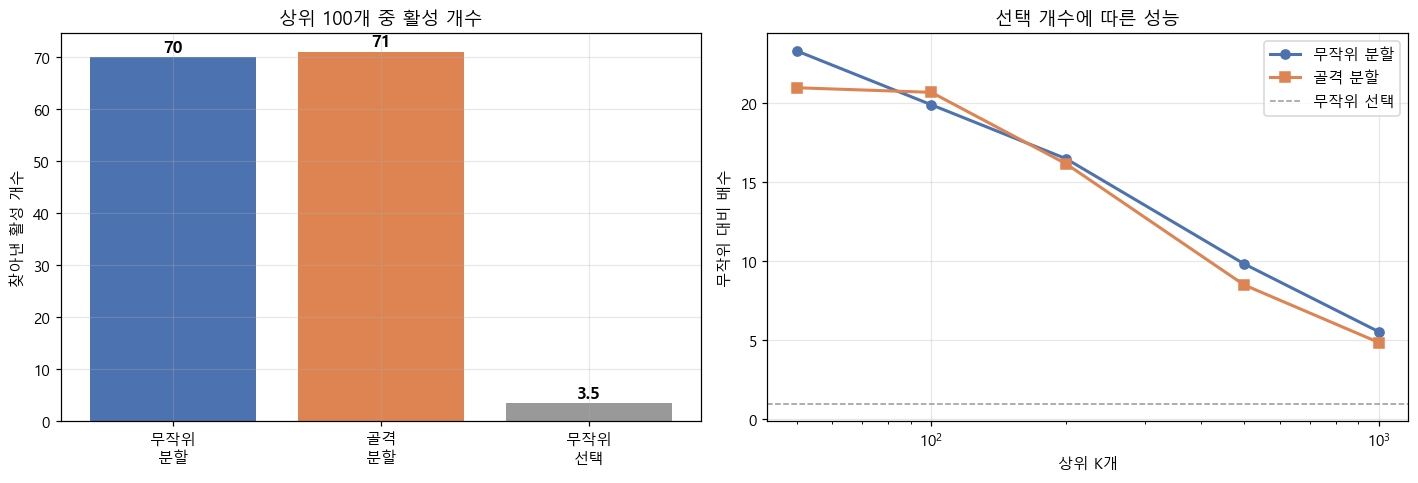

In [10]:
# ==================== 9번 셀 ====================
# 6번 셀과 똑같은 모델을 골격 분할 데이터로 학습시킵니다.
# 모델 설정은 하나도 바꾸지 않습니다.
# 달라지는 것은 오직 "데이터를 어떻게 나눴는가"뿐입니다.
# ================================================

print("=" * 60)
print("랜덤 포레스트 학습 (골격 분할)")
print("=" * 60)

# ------------------------------------------------------------
# 1) 골격 분할로 나눈 데이터를 준비합니다.
# ------------------------------------------------------------
X_train_scaffold = X[train_idx_scaffold]
X_test_scaffold  = X[test_idx_scaffold]

print(f"  학습용 : {len(X_train_scaffold):,} 개")
print(f"  검증용 : {len(X_test_scaffold):,} 개")
print()
print("  학습 중... (1~3분)")

# ------------------------------------------------------------
# 2) 6번 셀과 동일한 설정으로 모델을 새로 만듭니다.
# ------------------------------------------------------------
model_rf_scaffold = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)

t0 = time.time()
model_rf_scaffold.fit(X_train_scaffold, y_train_scaffold)
print(f"  완료 ({time.time() - t0:.1f}초)")

# ------------------------------------------------------------
# 3) 예측하고 평가합니다.
# ------------------------------------------------------------
prob_rf_scaffold = model_rf_scaffold.predict_proba(X_test_scaffold)[:, 1]

n_hit_s, n_rand_s, fold_s = evaluate_topk(y_test_scaffold, prob_rf_scaffold)

results["RF_scaffold"] = {
    "model":  "랜덤 포레스트",
    "split":  "골격",
    "n_hit":  n_hit_s,
    "n_rand": n_rand_s,
    "fold":   fold_s,
    "prob":   prob_rf_scaffold,
}


# ------------------------------------------------------------
# 4) 두 분할 결과를 나란히 비교합니다.
#    이것이 이 프로젝트의 핵심 표입니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print(f"핵심 결과 — 상위 {TOP_K}개 비교")
print("=" * 60)
print(f"{'분할 방식':<14} {'활성':>8} {'무작위':>10} {'배수':>10}")
print("-" * 46)

r1 = results["RF_random"]
r2 = results["RF_scaffold"]

print(f"{'무작위 분할':<14} {r1['n_hit']:>8} {r1['n_rand']:>10.1f} {r1['fold']:>9.1f}배")
print(f"{'골격 분할':<14} {r2['n_hit']:>8} {r2['n_rand']:>10.1f} {r2['fold']:>9.1f}배")
print("-" * 46)

drop_abs = r1["n_hit"] - r2["n_hit"]
drop_pct = drop_abs / r1["n_hit"] * 100 if r1["n_hit"] > 0 else 0

print(f"{'차이':<14} {drop_abs:>8} {'':>10} {r1['fold'] - r2['fold']:>9.1f}배")
print()
print(f"  → 골격을 분리하자 활성 발견이 {drop_pct:.0f}% 줄었습니다.")


# ------------------------------------------------------------
# 5) 상위 개수별로도 비교합니다.
# ------------------------------------------------------------
print()
print("--- 상위 개수별 비교 ---")
print(f"{'상위':>8} {'무작위분할':>12} {'골격분할':>12} {'감소율':>10}")
print("-" * 46)

for k in [50, 100, 200, 500, 1000]:
    h1, _, f1 = evaluate_topk(y_test_random,   prob_rf,          k=k)
    h2, _, f2 = evaluate_topk(y_test_scaffold, prob_rf_scaffold, k=k)
    drop = (h1 - h2) / h1 * 100 if h1 > 0 else 0
    print(f"{k:>8} {h1:>7}({f1:>4.1f}배) {h2:>7}({f2:>4.1f}배) {drop:>9.0f}%")


# ------------------------------------------------------------
# 6) 그림으로 확인합니다.
# ------------------------------------------------------------
ks = [50, 100, 200, 500, 1000]
folds_random   = [evaluate_topk(y_test_random,   prob_rf,          k=k)[2] for k in ks]
folds_scaffold = [evaluate_topk(y_test_scaffold, prob_rf_scaffold, k=k)[2] for k in ks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: 상위 100개 막대그래프
ax = axes[0]
bars = ax.bar(
    ["무작위\n분할", "골격\n분할", "무작위\n선택"],
    [r1["n_hit"], r2["n_hit"], r1["n_rand"]],
    color=["#4C72B0", "#DD8452", "#999999"],
)
for bar, val in zip(bars, [r1["n_hit"], r2["n_hit"], r1["n_rand"]]):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 1,
            f"{val:.1f}" if val < 10 else f"{int(val)}",
            ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("찾아낸 활성 개수")
ax.set_title(f"상위 {TOP_K}개 중 활성 개수")

# 오른쪽: 상위 개수별 배수 곡선
ax = axes[1]
ax.plot(ks, folds_random,   "o-", label="무작위 분할", color="#4C72B0", lw=2)
ax.plot(ks, folds_scaffold, "s-", label="골격 분할",   color="#DD8452", lw=2)
ax.axhline(1.0, color="#999999", ls="--", lw=1, label="무작위 선택")
ax.set_xscale("log")
ax.set_xlabel("상위 K개")
ax.set_ylabel("무작위 대비 배수")
ax.set_title("선택 개수에 따른 성능")
ax.legend()

plt.tight_layout()
plt.show()

## 9번 셀 결과 확인

### 예상과 다른 결과

| 상위 | 무작위 분할 | 골격 분할 | 감소 |
|---|---|---|---|
| 50 | 41 | 36 | 12% |
| 100 | 70 | 71 | -1% |
| 200 | 116 | 111 | 4% |
| 500 | 173 | 146 | 16% |
| 1000 | 195 | 167 | 14% |

**성능이 거의 떨어지지 않았습니다.** 상위 100개에서는 오히려 1개 늘었습니다.

골격을 완전히 분리했는데도 20배가 그대로 유지됐다는 뜻입니다.
예상은 크게 떨어지는 것이었습니다.

### 가능한 해석은 두 가지

**(1) 모델이 진짜로 일반화한다.**
처음 보는 골격에서도 활성을 찾아낼 수 있다는 뜻이고, 좋은 소식입니다.

**(2) 골격 분할이 충분한 통제가 아니다.**
Murcko 골격은 문자열이 정확히 같아야 같은 골격으로 칩니다.
고리에 메틸기 하나가 더 붙거나 고리 크기가 하나 다르면 **다른 골격**이 됩니다.

즉 골격 문자열은 달라도 구조적으로 거의 똑같은 분자들이
학습과 검증에 여전히 나뉘어 들어가 있을 수 있습니다.

### 어느 쪽인지 확인해야 합니다

두 해석은 결론이 정반대입니다. 그냥 넘어갈 수 없습니다.

확인 방법은 간단합니다. **검증 세트의 각 분자가 학습 세트에
얼마나 닮은 분자를 가지고 있는지** 직접 재보면 됩니다.

닮은 분자가 여전히 많다면 (2)이고, 없는데도 성능이 유지됐다면 (1)입니다.

다음 셀에서 이것을 측정합니다.

학습-검증 유사도 측정
(각 검증 분자마다 학습 세트에서 가장 닮은 분자를 찾습니다)
1~3분 걸립니다.

[무작위 분할]
  2,000 / 8,224 처리 중...
  4,000 / 8,224 처리 중...
  6,000 / 8,224 처리 중...
  8,000 / 8,224 처리 중...

[골격 분할]
  2,000 / 8,224 처리 중...
  4,000 / 8,224 처리 중...
  6,000 / 8,224 처리 중...
  8,000 / 8,224 처리 중...

검증 분자가 학습 세트와 얼마나 닮았는가
                      중앙값         평균        0.7이상        0.9이상
------------------------------------------------------------
무작위 분할              0.628      0.616        35.3%         4.3%
골격 분할               0.440      0.470         9.6%         1.1%

  ※ Tanimoto 0.7 이상이면 통상 '매우 유사한 화합물'로 봅니다.
     0.9 이상이면 사실상 같은 계열의 유사체입니다.

유사도 구간별 모델 성능 (골격 분할)
유사도 구간              분자수       실제활성       활성률         모델평균확률
------------------------------------------------------------
0.0 ~ 0.4         3,176         76     2.39%        0.0517
0.4 ~ 0.6         3,291         91     2.77%        0.0545
0.6 ~ 0.8         1,484         84     5.66%        0.0850
0.8 ~ 1.0           273         31    11.36%        0.130

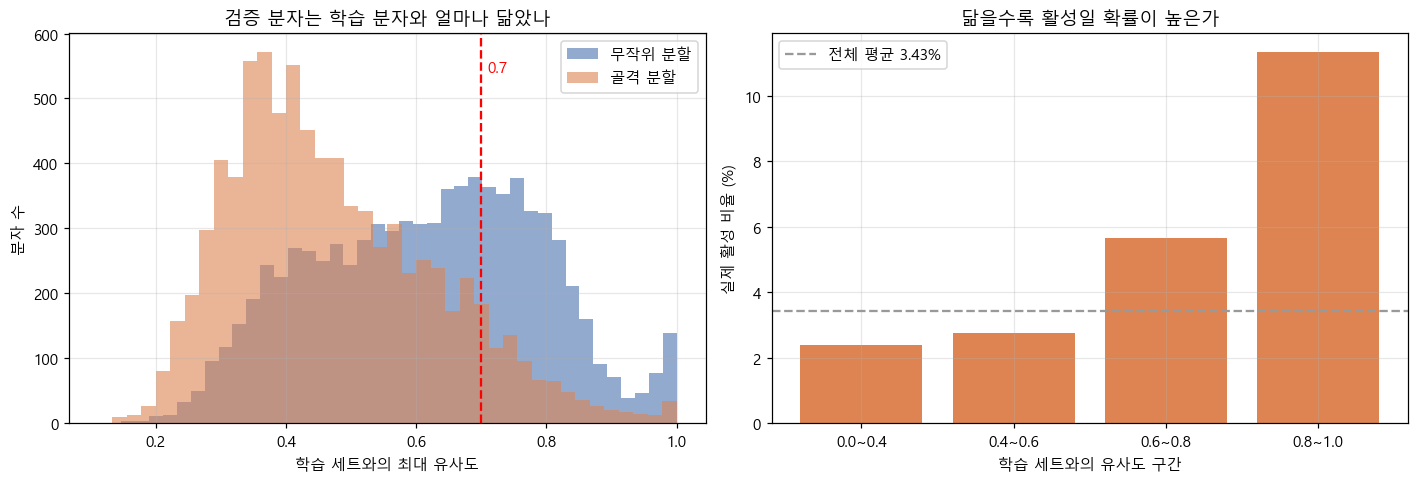

In [11]:
# ==================== 10번 셀 ====================
# 골격 분할이 실제로 "닮은 분자"를 갈라놓았는지 확인합니다.
#
# 방법: 검증 세트의 분자 하나하나에 대해
#       학습 세트에서 가장 닮은 분자를 찾아 유사도를 잽니다.
#       이 값이 높으면 여전히 비슷한 것을 보고 맞힌 것입니다.
# =================================================

print("=" * 60)
print("학습-검증 유사도 측정")
print("=" * 60)
print("(각 검증 분자마다 학습 세트에서 가장 닮은 분자를 찾습니다)")
print("1~3분 걸립니다.")
print()


# ------------------------------------------------------------
# 1) 유사도를 계산하는 함수를 만듭니다.
#
#    Tanimoto 유사도: 두 지문에서
#    (둘 다 1인 칸) / (둘 중 하나라도 1인 칸)
#    1.0이면 완전히 같고, 0이면 공통 부분이 없습니다.
#
#    행렬 연산으로 한 번에 계산하면 훨씬 빠릅니다.
# ------------------------------------------------------------
def max_similarity_to_train(X_test_part, X_train_part, batch_size=500):
    """
    검증 분자마다 학습 세트 내 최대 Tanimoto 유사도를 구합니다.
    메모리를 아끼려고 batch_size개씩 나눠서 계산합니다.
    """
    # float으로 바꿔야 계산이 됩니다
    train_f = X_train_part.astype(np.float32)
    # 학습 분자마다 켜진 비트 수 (미리 계산해 두면 빠릅니다)
    train_bits = train_f.sum(axis=1)

    max_sims = []

    for start in range(0, len(X_test_part), batch_size):
        batch = X_test_part[start:start + batch_size].astype(np.float32)
        batch_bits = batch.sum(axis=1)

        # 공통으로 1인 칸의 수 (행렬 곱으로 한 번에)
        common = batch @ train_f.T

        # 둘 중 하나라도 1인 칸의 수 = A + B - 공통
        union = batch_bits[:, None] + train_bits[None, :] - common

        # 0으로 나누는 것을 막습니다
        union = np.where(union == 0, 1, union)

        sim = common / union
        max_sims.append(sim.max(axis=1))

        if (start + batch_size) % 2000 == 0:
            print(f"  {min(start + batch_size, len(X_test_part)):,} / "
                  f"{len(X_test_part):,} 처리 중...")

    return np.concatenate(max_sims)


# ------------------------------------------------------------
# 2) 두 분할 방식 모두에 대해 계산합니다.
# ------------------------------------------------------------
print("[무작위 분할]")
sim_random = max_similarity_to_train(X_test_random, X_train_random)

print()
print("[골격 분할]")
sim_scaffold = max_similarity_to_train(X_test_scaffold, X_train_scaffold)


# ------------------------------------------------------------
# 3) 결과를 비교합니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("검증 분자가 학습 세트와 얼마나 닮았는가")
print("=" * 60)
print(f"{'':14} {'중앙값':>10} {'평균':>10} {'0.7이상':>12} {'0.9이상':>12}")
print("-" * 60)

for name, sim in [("무작위 분할", sim_random), ("골격 분할", sim_scaffold)]:
    pct_07 = (sim >= 0.7).mean() * 100
    pct_09 = (sim >= 0.9).mean() * 100
    print(f"{name:<14} {np.median(sim):>10.3f} {sim.mean():>10.3f} "
          f"{pct_07:>11.1f}% {pct_09:>11.1f}%")

print()
print("  ※ Tanimoto 0.7 이상이면 통상 '매우 유사한 화합물'로 봅니다.")
print("     0.9 이상이면 사실상 같은 계열의 유사체입니다.")


# ------------------------------------------------------------
# 4) 유사도가 높은 것과 낮은 것으로 나눠서
#    모델 성능이 다른지 확인합니다.
#
#    이것이 핵심입니다. 닮은 것에서만 잘 맞힌다면
#    일반화가 아니라 암기입니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("유사도 구간별 모델 성능 (골격 분할)")
print("=" * 60)

# 유사도 구간을 나눕니다
bins = [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]

print(f"{'유사도 구간':<14} {'분자수':>8} {'실제활성':>10} {'활성률':>9} {'모델평균확률':>14}")
print("-" * 60)

for low, high in bins:
    mask = (sim_scaffold >= low) & (sim_scaffold < high)
    n     = int(mask.sum())
    if n == 0:
        continue
    n_act = int(y_test_scaffold[mask].sum())
    rate  = n_act / n * 100
    avg_p = prob_rf_scaffold[mask].mean()
    print(f"{low:.1f} ~ {high:.1f}      {n:>8,} {n_act:>10,} {rate:>8.2f}% {avg_p:>13.4f}")


# ------------------------------------------------------------
# 5) 상위 100개로 뽑힌 분자들의 유사도를 봅니다.
#    모델이 고른 것들이 사실 학습에서 본 것과 닮은 것인지 확인합니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print(f"모델이 고른 상위 {TOP_K}개의 유사도")
print("=" * 60)

top_idx = np.argsort(prob_rf_scaffold)[::-1][:TOP_K]
sim_top = sim_scaffold[top_idx]

print(f"  상위 {TOP_K}개 평균 유사도 : {sim_top.mean():.3f}")
print(f"  검증 세트 전체 평균     : {sim_scaffold.mean():.3f}")
print()

if sim_top.mean() > sim_scaffold.mean() + 0.05:
    print("  → 모델은 학습 세트와 닮은 분자를 우선적으로 골랐습니다.")
else:
    print("  → 모델이 특별히 닮은 분자만 고른 것은 아닙니다.")


# ------------------------------------------------------------
# 6) 그림으로 확인합니다.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: 유사도 분포 비교
ax = axes[0]
ax.hist(sim_random,   bins=40, alpha=0.6, label="무작위 분할", color="#4C72B0")
ax.hist(sim_scaffold, bins=40, alpha=0.6, label="골격 분할",   color="#DD8452")
ax.axvline(0.7, color="red", ls="--", lw=1.5)
ax.text(0.71, ax.get_ylim()[1] * 0.9, "0.7", color="red", fontsize=10)
ax.set_xlabel("학습 세트와의 최대 유사도")
ax.set_ylabel("분자 수")
ax.set_title("검증 분자는 학습 분자와 얼마나 닮았나")
ax.legend()

# 오른쪽: 유사도 구간별 실제 활성률
ax = axes[1]
labels, rates = [], []
for low, high in bins:
    mask = (sim_scaffold >= low) & (sim_scaffold < high)
    if mask.sum() == 0:
        continue
    labels.append(f"{low:.1f}~{high:.1f}")
    rates.append(y_test_scaffold[mask].mean() * 100)

ax.bar(labels, rates, color="#DD8452")
ax.axhline(y_test_scaffold.mean() * 100, color="#999999", ls="--",
           label=f"전체 평균 {y_test_scaffold.mean()*100:.2f}%")
ax.set_xlabel("학습 세트와의 유사도 구간")
ax.set_ylabel("실제 활성 비율 (%)")
ax.set_title("닮을수록 활성일 확률이 높은가")
ax.legend()

plt.tight_layout()
plt.show()

## 10번 셀 결과 확인

검증 세트의 분자마다 "학습 세트에 얼마나 닮은 분자가 있는지"를 쟀습니다.
유사도 1.0이면 똑같은 분자, 0.7 이상이면 매우 닮은 분자로 봅니다.

### 골격 분할은 제대로 작동했다

| | 닮은 분자(0.7 이상)를 가진 비율 |
|---|---|
| 무작위 분할 | 35.3% |
| 골격 분할 | **9.6%** |

무작위로 나눴을 땐 검증 분자 3개 중 1개가 학습 세트에 닮은 짝이 있었습니다.
골격 분할이 이걸 4분의 1 수준으로 줄였습니다.

### 그런데 성능은 왜 안 떨어졌나

**닮을수록 활성일 확률이 높습니다.**

| 유사도 | 실제 활성률 |
|---|---|
| 0.4 미만 | 2.4% |
| 0.8 이상 | **11.4%** |

그리고 모델이 고른 상위 100개의 평균 유사도는 **0.726**,
검증 세트 전체 평균은 0.470이었습니다.

즉 골격을 갈라놔도 닮은 분자가 9.6% 남아 있었고,
**모델은 그 9.6%를 정확히 골라냈습니다.**

### 정리

20배라는 성능은 "처음 보는 구조를 찾아내는 능력"이 아니라
**닮은 것을 골라내는 능력**에 상당 부분 기대고 있습니다.

그렇다면 진짜 질문은 하나입니다.

> **닮은 분자가 전혀 없을 때도 모델이 쓸모가 있는가?**

유사도 0.4 미만인 3,176개만 떼어놓고 보면 답이 나옵니다. 다음 셀에서 확인합니다.

유사도 구간별 모델 성능
(각 구간 안에서만 순위를 매기고 상위 10%를 봅니다)

유사도               분자수      활성     상위10%      적중      무작위       배수
--------------------------------------------------------------------
0.0 ~ 0.4     3,176      76       317      27      7.6     3.6배
0.4 ~ 0.6     3,291      91       329      46      9.1     5.1배
0.6 ~ 0.8     1,484      84       148      62      8.4     7.4배
0.8 ~ 1.0       273      31        27      22      3.1     7.2배

가장 어려운 구간: 유사도 0.4 미만
  분자 수   : 3,176 개
  활성      : 76 개 (2.39%)

      상위      적중       무작위       배수
------------------------------------
      50      12       1.2    10.0배
     100      17       2.4     7.1배
     200      25       4.8     5.2배
     300      27       7.2     3.8배

------------------------------------------------------------
  → 닮은 분자가 없어도 무작위보다 7.1배 낫습니다.
    모델은 유사도에만 의존하지 않습니다.


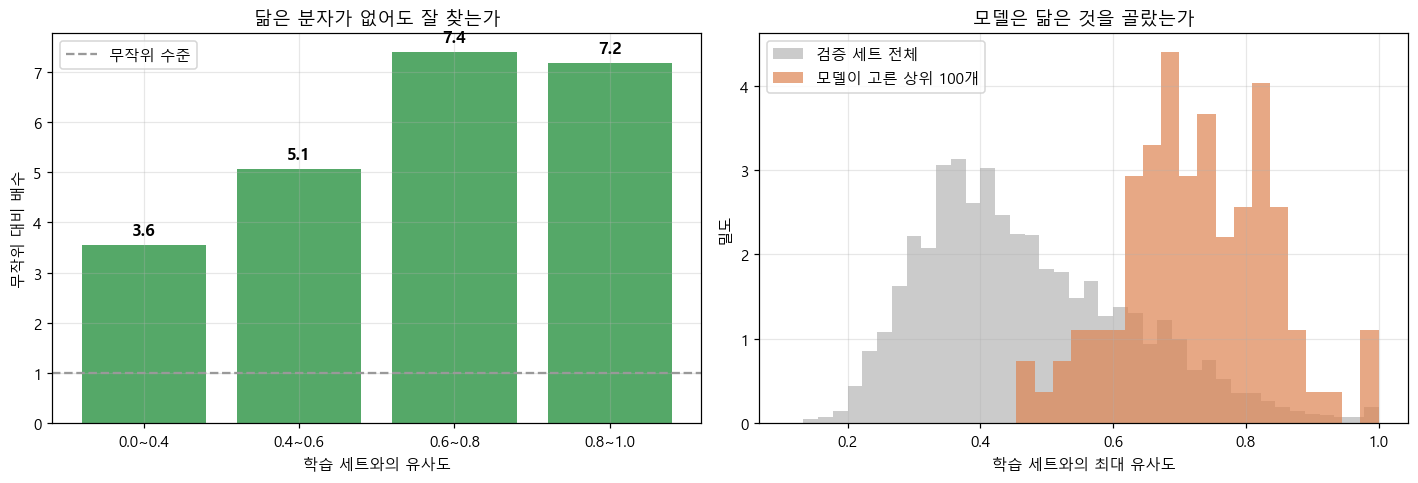

In [12]:
# ==================== 11번 셀 ====================
# 유사도 구간별로 나눠서 모델 성능을 따로 측정합니다.
#
# 핵심 질문: 학습 세트에 닮은 분자가 없는 경우에도
#            모델이 무작위보다 나은가?
# =================================================

print("=" * 60)
print("유사도 구간별 모델 성능")
print("=" * 60)
print("(각 구간 안에서만 순위를 매기고 상위 10%를 봅니다)")
print()


# ------------------------------------------------------------
# 1) 구간별로 나눠서 평가합니다.
#
#    구간마다 분자 수가 다르므로 상위 100개 대신
#    "상위 10%"를 보는 것이 공정합니다.
# ------------------------------------------------------------
bins = [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]

print(f"{'유사도':<12} {'분자수':>8} {'활성':>7} {'상위10%':>9} "
      f"{'적중':>7} {'무작위':>8} {'배수':>8}")
print("-" * 68)

bin_results = []

for low, high in bins:
    mask = (sim_scaffold >= low) & (sim_scaffold < high)
    n = int(mask.sum())
    if n < 50:          # 너무 작으면 건너뜁니다
        continue

    y_bin    = y_test_scaffold[mask]
    prob_bin = prob_rf_scaffold[mask]

    n_act = int(y_bin.sum())
    k     = max(10, int(n * 0.1))     # 이 구간의 상위 10%

    # 구간 안에서만 순위를 매깁니다
    order  = np.argsort(prob_bin)[::-1]
    n_hit  = int(y_bin[order[:k]].sum())
    n_rand = k * y_bin.mean()
    fold   = n_hit / n_rand if n_rand > 0 else 0

    print(f"{low:.1f} ~ {high:.1f}  {n:>8,} {n_act:>7,} {k:>9,} "
          f"{n_hit:>7} {n_rand:>8.1f} {fold:>7.1f}배")

    bin_results.append({
        "label": f"{low:.1f}~{high:.1f}",
        "n": n, "n_act": n_act, "n_hit": n_hit,
        "n_rand": n_rand, "fold": fold,
    })


# ------------------------------------------------------------
# 2) 가장 어려운 구간(유사도 0.4 미만)을 자세히 봅니다.
#    여기가 진짜 일반화 능력입니다.
# ------------------------------------------------------------
print()
print("=" * 60)
print("가장 어려운 구간: 유사도 0.4 미만")
print("=" * 60)

hard_mask = sim_scaffold < 0.4
y_hard    = y_test_scaffold[hard_mask]
prob_hard = prob_rf_scaffold[hard_mask]

print(f"  분자 수   : {int(hard_mask.sum()):,} 개")
print(f"  활성      : {int(y_hard.sum()):,} 개 ({y_hard.mean()*100:.2f}%)")
print()
print(f"{'상위':>8} {'적중':>7} {'무작위':>9} {'배수':>8}")
print("-" * 36)

for k in [50, 100, 200, 300]:
    if k > len(y_hard):
        continue
    order  = np.argsort(prob_hard)[::-1]
    n_hit  = int(y_hard[order[:k]].sum())
    n_rand = k * y_hard.mean()
    fold   = n_hit / n_rand if n_rand > 0 else 0
    print(f"{k:>8} {n_hit:>7} {n_rand:>9.1f} {fold:>7.1f}배")


# ------------------------------------------------------------
# 3) 결론을 자동으로 판정합니다.
# ------------------------------------------------------------
order    = np.argsort(prob_hard)[::-1]
hit_100  = int(y_hard[order[:100]].sum())
rand_100 = 100 * y_hard.mean()
fold_100 = hit_100 / rand_100 if rand_100 > 0 else 0

print()
print("-" * 60)
if fold_100 >= 3:
    print(f"  → 닮은 분자가 없어도 무작위보다 {fold_100:.1f}배 낫습니다.")
    print(f"    모델은 유사도에만 의존하지 않습니다.")
elif fold_100 >= 1.5:
    print(f"  → 닮은 분자가 없으면 {fold_100:.1f}배로 떨어집니다.")
    print(f"    성능의 상당 부분이 유사도에서 나왔습니다.")
else:
    print(f"  → 닮은 분자가 없으면 무작위와 거의 같습니다 ({fold_100:.1f}배).")
    print(f"    모델은 사실상 유사도만 보고 있었습니다.")


# ------------------------------------------------------------
# 4) 그림
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# 왼쪽: 구간별 배수
ax = axes[0]
labels = [r["label"] for r in bin_results]
folds  = [r["fold"]  for r in bin_results]
colors = ["#C44E52" if f < 3 else "#55A868" for f in folds]

bars = ax.bar(labels, folds, color=colors)
for bar, f in zip(bars, folds):
    ax.text(bar.get_x() + bar.get_width()/2, f + 0.2,
            f"{f:.1f}", ha="center", fontsize=11, fontweight="bold")
ax.axhline(1.0, color="#999999", ls="--", lw=1.5, label="무작위 수준")
ax.set_xlabel("학습 세트와의 유사도")
ax.set_ylabel("무작위 대비 배수")
ax.set_title("닮은 분자가 없어도 잘 찾는가")
ax.legend()

# 오른쪽: 상위 100개의 유사도 분포
ax = axes[1]
top_idx = np.argsort(prob_rf_scaffold)[::-1][:TOP_K]
ax.hist(sim_scaffold, bins=40, alpha=0.5,
        label="검증 세트 전체", color="#999999", density=True)
ax.hist(sim_scaffold[top_idx], bins=20, alpha=0.7,
        label=f"모델이 고른 상위 {TOP_K}개", color="#DD8452", density=True)
ax.set_xlabel("학습 세트와의 최대 유사도")
ax.set_ylabel("밀도")
ax.set_title("모델은 닮은 것을 골랐는가")
ax.legend()

plt.tight_layout()
plt.show()

## 11번 셀 결과 확인

### 닮은 분자가 없어도 작동한다

가장 어려운 구간(유사도 0.4 미만, 3,176개)만 떼어놓고 본 결과입니다.

| 상위 | 적중 | 무작위 | 배수 |
|---|---|---|---|
| 50 | 12 | 1.2 | **10.0배** |
| 100 | 17 | 2.4 | **7.1배** |
| 300 | 27 | 7.2 | 3.8배 |

학습 세트에 닮은 분자가 하나도 없는 상황에서도 **7배** 성능이 나왔습니다.
모델이 유사도만 보고 있었던 것은 아닙니다.

### 다만 유사도가 성능을 끌어올리는 것도 사실

| 유사도 구간 | 배수 |
|---|---|
| 0.0 ~ 0.4 | 3.6배 |
| 0.4 ~ 0.6 | 5.1배 |
| 0.6 ~ 0.8 | 7.4배 |
| 0.8 ~ 1.0 | 7.2배 |

닮을수록 성능이 올라갑니다. 0.4 미만과 0.6 이상 사이에 2배 차이가 납니다.

### 결론

**두 가지가 동시에 참입니다.**

1. 모델은 처음 보는 구조에서도 활성을 찾아낼 수 있다 (7배)
2. 하지만 전체 성능 20배 중 상당 부분은 닮은 분자에서 나왔다

신약 발굴 관점에서 중요한 건 1번입니다.
**새로운 골격을 찾는 것이 목적이라면 기대할 수 있는 성능은 20배가 아니라 7배**입니다.

이 구분이 이 프로젝트의 핵심 결과입니다.
단일 숫자로 "20배"만 보고하면 실제보다 3배 부풀린 셈이 됩니다.

천연물 유사도(NP-likeness) 분석


reading NP model ...
model in


  계산 완료: 8,224 개
  범위: -3.02 ~ 4.03 (중앙값 -0.15)
  천연물형 기준: NP score >= 0.51  →  2,056 개 (상위 25%)

천연물형 vs 합성형
                분자수       활성률         학습과의유사도      배수(상위10%)
------------------------------------------------------------
천연물형          2,056     3.11%          0.422           4.5배
합성형           6,168     3.53%          0.487           6.1배


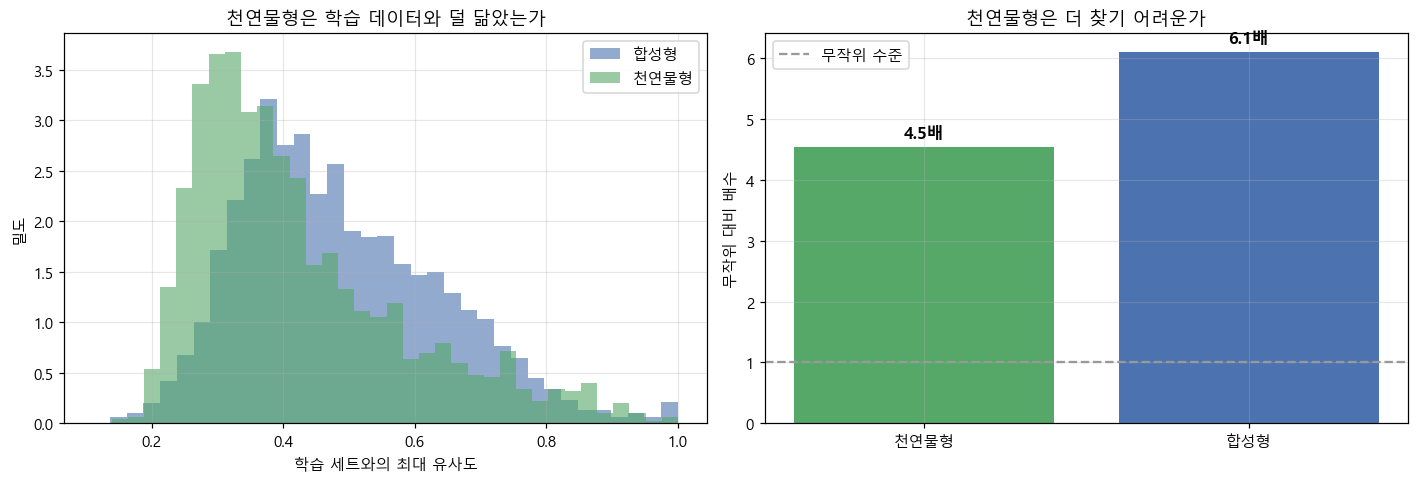

In [13]:
# ==================== 12번 셀 ====================
# 천연물스러운 분자는 더 찾기 어려운가?
#
# NP-likeness score: 분자가 천연물을 얼마나 닮았는지 나타내는 점수.
# 값이 클수록 천연물에 가깝고, 작을수록 합성 화합물에 가깝습니다.
# =================================================

from rdkit.Chem import RDConfig
import os, sys, pickle

sys.path.append(os.path.join(RDConfig.RDContribDir, "NP_Score"))
import npscorer

print("=" * 60)
print("천연물 유사도(NP-likeness) 분석")
print("=" * 60)

# --- 1) 검증 세트 분자의 NP score 계산 ---
fscore = npscorer.readNPModel()
mols_test = data["mol"].iloc[test_idx_scaffold].values
np_score = np.array([npscorer.scoreMol(m, fscore) for m in mols_test])

print(f"  계산 완료: {len(np_score):,} 개")
print(f"  범위: {np_score.min():.2f} ~ {np_score.max():.2f} (중앙값 {np.median(np_score):.2f})")

# --- 2) 천연물스러운 쪽 상위 25%를 '천연물형'으로 정의 ---
cut = np.percentile(np_score, 75)
is_np = np_score >= cut

print(f"  천연물형 기준: NP score >= {cut:.2f}  →  {int(is_np.sum()):,} 개 (상위 25%)")

# --- 3) 천연물형 vs 합성형 비교 ---
print()
print("=" * 60)
print("천연물형 vs 합성형")
print("=" * 60)
print(f"{'':10} {'분자수':>8} {'활성률':>9} {'학습과의유사도':>15} {'배수(상위10%)':>14}")
print("-" * 60)

np_summary = []
for label, mask in [("천연물형", is_np), ("합성형", ~is_np)]:
    y_g, p_g, s_g = y_test_scaffold[mask], prob_rf_scaffold[mask], sim_scaffold[mask]
    k = int(mask.sum() * 0.1)
    order = np.argsort(p_g)[::-1]
    hit = int(y_g[order[:k]].sum())
    rand = k * y_g.mean()
    fold = hit / rand if rand > 0 else 0

    print(f"{label:<10} {int(mask.sum()):>8,} {y_g.mean()*100:>8.2f}% "
          f"{s_g.mean():>14.3f} {fold:>13.1f}배")
    np_summary.append({"label": label, "fold": fold, "sim": s_g.mean()})

# --- 4) 그림 ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.hist(sim_scaffold[~is_np], bins=35, alpha=0.6, label="합성형", color="#4C72B0", density=True)
ax.hist(sim_scaffold[is_np],  bins=35, alpha=0.6, label="천연물형", color="#55A868", density=True)
ax.set_xlabel("학습 세트와의 최대 유사도")
ax.set_ylabel("밀도")
ax.set_title("천연물형은 학습 데이터와 덜 닮았는가")
ax.legend()

ax = axes[1]
bars = ax.bar([d["label"] for d in np_summary], [d["fold"] for d in np_summary],
              color=["#55A868", "#4C72B0"])
for bar, d in zip(bars, np_summary):
    ax.text(bar.get_x() + bar.get_width()/2, d["fold"] + 0.15,
            f"{d['fold']:.1f}배", ha="center", fontsize=11, fontweight="bold")
ax.axhline(1.0, color="#999999", ls="--", lw=1.5, label="무작위 수준")
ax.set_ylabel("무작위 대비 배수")
ax.set_title("천연물형은 더 찾기 어려운가")
ax.legend()

plt.tight_layout()
plt.show()

## 12번 셀 결과 확인

NP-likeness는 분자가 천연물을 얼마나 닮았는지 나타내는 점수입니다.
상위 25%(2,056개)를 천연물형으로 놓고 나머지와 비교했습니다.

### 천연물형은 더 찾기 어렵다

| | 분자 수 | 학습 세트와의 유사도 | 배수 |
|---|---|---|---|
| 천연물형 | 2,056 | 0.422 | **4.5배** |
| 합성형 | 6,168 | 0.487 | **6.1배** |

천연물형이 합성형보다 **26% 낮은 성능**을 보였습니다.

### 이유

학습 세트와의 유사도가 낮습니다(0.422 vs 0.487).
스크리닝 라이브러리 대부분이 합성 화합물이라,
천연물형 분자는 참고할 만한 닮은 예시가 적습니다.

11번 셀에서 확인했듯 유사도가 낮으면 성능이 떨어집니다.
천연물형이 불리한 것은 그 결과입니다.

### 의미

천연물에서 활성 화합물을 찾을 때
합성 화합물로 학습한 모델을 그대로 쓰면 성능이 떨어집니다.

활성률 자체는 천연물형 3.11%, 합성형 3.53%로 큰 차이가 없습니다.
**천연물이 덜 활성인 게 아니라, 모델이 천연물을 덜 찾아내는 것**입니다.

In [14]:
# ==================== 13번 셀 ====================
# 딥러닝 모델로 같은 문제를 풀어봅니다.
# 입력은 동일한 지문, 구조는 은닉층 2개짜리 단순한 신경망입니다.
#
# 질문: 딥러닝이 랜덤 포레스트보다 나은가?
#       특히 유사도가 낮은 구간에서 나은가?
# =================================================

import torch
import torch.nn as nn

torch.manual_seed(RANDOM_SEED)

print("=" * 60)
print("신경망 학습 (골격 분할)")
print("=" * 60)

# --- 1) 데이터를 텐서로 변환 ---
Xtr = torch.tensor(X_train_scaffold, dtype=torch.float32)
ytr = torch.tensor(y_train_scaffold, dtype=torch.float32)
Xte = torch.tensor(X_test_scaffold,  dtype=torch.float32)

# --- 2) 모델 정의: 2048 → 256 → 64 → 1 ---
model_nn = nn.Sequential(
    nn.Linear(FP_BITS, 256), nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(256, 64),      nn.ReLU(), nn.Dropout(0.3),
    nn.Linear(64, 1),
)

# 활성이 3.5%뿐이라 그냥 두면 전부 '비활성'으로 답합니다.
# pos_weight로 활성 쪽에 가중치를 줍니다.
pos_weight = torch.tensor([(ytr == 0).sum() / (ytr == 1).sum()])
loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_nn.parameters(), lr=1e-3)

print(f"  구조       : {FP_BITS} → 256 → 64 → 1")
print(f"  활성 가중치 : {pos_weight.item():.1f}")
print()

# --- 3) 학습 ---
EPOCHS, BATCH = 30, 256
n_train = len(Xtr)

for epoch in range(EPOCHS):
    model_nn.train()
    perm = torch.randperm(n_train)
    total_loss = 0.0

    for i in range(0, n_train, BATCH):
        idx = perm[i:i + BATCH]
        optimizer.zero_grad()
        out = model_nn(Xtr[idx]).squeeze(1)
        loss = loss_fn(out, ytr[idx])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(idx)

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:>2}/{EPOCHS}  loss {total_loss/n_train:.4f}")

# --- 4) 예측 ---
model_nn.eval()
with torch.no_grad():
    prob_nn = torch.sigmoid(model_nn(Xte).squeeze(1)).numpy()

# --- 5) 랜덤 포레스트와 비교 ---
print()
print("=" * 60)
print("랜덤 포레스트 vs 신경망 (골격 분할)")
print("=" * 60)
print(f"{'상위':>8} {'랜덤포레스트':>16} {'신경망':>14}")
print("-" * 42)

for k in [50, 100, 200, 500]:
    h_rf, _, f_rf = evaluate_topk(y_test_scaffold, prob_rf_scaffold, k=k)
    h_nn, _, f_nn = evaluate_topk(y_test_scaffold, prob_nn, k=k)
    print(f"{k:>8} {h_rf:>9}({f_rf:>4.1f}배) {h_nn:>7}({f_nn:>4.1f}배)")

# --- 6) 어려운 구간(유사도 0.4 미만)에서 비교 ---
print()
print("--- 유사도 0.4 미만 구간 (상위 100개) ---")
hard = sim_scaffold < 0.4
y_h = y_test_scaffold[hard]
rand_h = 100 * y_h.mean()

for name, p in [("랜덤 포레스트", prob_rf_scaffold), ("신경망", prob_nn)]:
    p_h = p[hard]
    hit = int(y_h[np.argsort(p_h)[::-1][:100]].sum())
    print(f"  {name:<14} {hit:>3}개  ({hit/rand_h:.1f}배)")

# --- 7) 결과 저장 ---
h_nn, r_nn, f_nn = evaluate_topk(y_test_scaffold, prob_nn)
results["NN_scaffold"] = {
    "model": "신경망", "split": "골격",
    "n_hit": h_nn, "n_rand": r_nn, "fold": f_nn, "prob": prob_nn,
}

신경망 학습 (골격 분할)
  구조       : 2048 → 256 → 64 → 1
  활성 가중치 : 27.3

  epoch 10/30  loss 0.0766
  epoch 20/30  loss 0.0369
  epoch 30/30  loss 0.0292

랜덤 포레스트 vs 신경망 (골격 분할)
      상위           랜덤포레스트            신경망
------------------------------------------
      50        36(21.0배)      41(23.9배)
     100        71(20.7배)      63(18.4배)
     200       111(16.2배)      86(12.5배)
     500       146( 8.5배)     112( 6.5배)

--- 유사도 0.4 미만 구간 (상위 100개) ---
  랜덤 포레스트         17개  (7.1배)
  신경망              5개  (2.1배)


## 13번 셀 결과 확인

### 전체 성능은 비슷, 어려운 구간에서 갈림

| 상위 | 랜덤 포레스트 | 신경망 |
|---|---|---|
| 50 | 36 (21.0배) | **41 (23.9배)** |
| 100 | **71 (20.7배)** | 63 (18.4배) |
| 200 | **111 (16.2배)** | 86 (12.5배) |
| 500 | **146 (8.5배)** | 112 (6.5배) |

**유사도 0.4 미만 구간 (상위 100개)**

| | 적중 | 배수 |
|---|---|---|
| 랜덤 포레스트 | **17개** | **7.1배** |
| 신경망 | 5개 | 2.1배 |

닮은 분자가 없는 상황에서 신경망은 랜덤 포레스트의 3분의 1 수준입니다.

### 왜 이런 결과가 나왔나

학습 손실이 0.0766 → 0.0292로 계속 떨어졌습니다.
학습 데이터를 점점 더 잘 외운 것인데, 검증 성능은 따라오지 않았습니다.

활성이 1,161개뿐인 데이터에 파라미터 53만 개 모델을 학습시켰습니다.
데이터에 비해 모델이 커서 암기 쪽으로 기울었습니다.

### 다만 입력 방식의 한계일 수도 있다

이 신경망은 **분자 지문**을 입력으로 받습니다.
지문은 "어떤 부분 구조가 있는가"만 알려줄 뿐,
원자들이 어떻게 연결되어 있는지는 담지 못합니다.

이 분야의 표준 딥러닝 접근은 "GNN(그래프 신경망)"입니다.
분자를 그래프 그대로 넣어 연결 관계까지 학습합니다.

딥러닝 자체가 불리한 것인지, 입력 방식 때문인지 구분하려면
GNN까지 확인해야 합니다. 다음 셀에서 확인합니다.

In [15]:
# ==================== 14번 셀 ====================
# GNN을 쓰려면 분자를 그래프 형태로 바꿔야 합니다.
#
# 그래프 = 노드(원자) + 엣지(결합)
#   노드 특징: 원자 번호, 결합 수, 전하, 방향족 여부 등
#   엣지: 어떤 원자끼리 연결되어 있는가
# =================================================

from torch_geometric.data import Data
from torch_geometric.loader import DataLoader

print("=" * 60)
print("분자 → 그래프 변환")
print("=" * 60)


def mol_to_graph(mol, label):
    """RDKit 분자 하나를 PyTorch Geometric 그래프로 바꿉니다."""

    # --- 노드 특징: 원자마다 5개 숫자 ---
    atom_features = []
    for atom in mol.GetAtoms():
        atom_features.append([
            atom.GetAtomicNum(),          # 원자 번호 (C=6, N=7, O=8 ...)
            atom.GetDegree(),             # 연결된 원자 수
            atom.GetFormalCharge(),       # 전하
            int(atom.GetIsAromatic()),    # 방향족인가
            atom.GetTotalNumHs(),         # 붙어 있는 수소 수
        ])
    x = torch.tensor(atom_features, dtype=torch.float)

    # --- 엣지: 결합 정보 (양방향으로 넣습니다) ---
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges.append([i, j])
        edges.append([j, i])

    if len(edges) == 0:            # 원자 1개짜리 분자 대비
        edge_index = torch.zeros((2, 0), dtype=torch.long)
    else:
        edge_index = torch.tensor(edges, dtype=torch.long).t()

    return Data(x=x, edge_index=edge_index,
                y=torch.tensor([label], dtype=torch.float))


# --- 학습용/검증용 그래프 만들기 ---
print("변환 중... (1~2분)")

graphs_train, graphs_test = [], []

for idx in train_idx_scaffold:
    graphs_train.append(mol_to_graph(data["mol"].iloc[idx], y[idx]))

for idx in test_idx_scaffold:
    graphs_test.append(mol_to_graph(data["mol"].iloc[idx], y[idx]))

print(f"  학습용 : {len(graphs_train):,} 개")
print(f"  검증용 : {len(graphs_test):,} 개")

# --- 변환 결과 확인 ---
g = graphs_train[0]
print()
print("--- 첫 번째 그래프 ---")
print(f"  원자 수      : {g.x.shape[0]}")
print(f"  노드 특징 수 : {g.x.shape[1]}")
print(f"  엣지 수      : {g.edge_index.shape[1]} (양방향이라 결합 수의 2배)")
print(f"  라벨         : {int(g.y.item())}")

n_atoms = [gr.x.shape[0] for gr in graphs_train]
print()
print(f"  원자 수 분포 : 최소 {min(n_atoms)}, 중앙값 {int(np.median(n_atoms))}, 최대 {max(n_atoms)}")

분자 → 그래프 변환
변환 중... (1~2분)
  학습용 : 32,896 개
  검증용 : 8,224 개

--- 첫 번째 그래프 ---
  원자 수      : 21
  노드 특징 수 : 5
  엣지 수      : 48 (양방향이라 결합 수의 2배)
  라벨         : 0

  원자 수 분포 : 최소 2, 중앙값 23, 최대 189


In [16]:
# ==================== 15번 셀 ====================
# GNN(그래프 신경망)으로 학습합니다.
#
# 원리: 원자마다 이웃 원자의 정보를 받아 자신을 갱신합니다.
#       이를 여러 번 반복하면 각 원자가 주변 환경을 알게 되고,
#       마지막에 전체를 합쳐 분자 하나의 특징으로 만듭니다.
# =================================================

from torch_geometric.nn import GCNConv, global_mean_pool

torch.manual_seed(RANDOM_SEED)

print("=" * 60)
print("GNN 학습 (골격 분할)")
print("=" * 60)


class SimpleGNN(nn.Module):
    def __init__(self, in_dim=5, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden)   # 이웃 정보 1단계
        self.conv2 = GCNConv(hidden, hidden)   # 이웃의 이웃까지
        self.conv3 = GCNConv(hidden, hidden)   # 3단계
        self.fc    = nn.Linear(hidden, 1)
        self.drop  = nn.Dropout(0.3)

    def forward(self, d):
        h = torch.relu(self.conv1(d.x, d.edge_index))
        h = torch.relu(self.conv2(h, d.edge_index))
        h = torch.relu(self.conv3(h, d.edge_index))
        h = global_mean_pool(h, d.batch)       # 원자들을 분자 하나로 합침
        return self.fc(self.drop(h)).squeeze(1)


model_gnn = SimpleGNN()
n_params = sum(p.numel() for p in model_gnn.parameters())

loss_fn_gnn   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_gnn = torch.optim.Adam(model_gnn.parameters(), lr=1e-3)

print(f"  구조       : GCN 3층 (은닉 64) → 평균 풀링 → 출력")
print(f"  파라미터   : {n_params:,} 개  (MLP는 53만 개)")
print()

# --- 학습 ---
loader_train = DataLoader(graphs_train, batch_size=128, shuffle=True)
loader_test  = DataLoader(graphs_test,  batch_size=256, shuffle=False)

EPOCHS_GNN = 30
for epoch in range(EPOCHS_GNN):
    model_gnn.train()
    total = 0.0
    for batch in loader_train:
        optimizer_gnn.zero_grad()
        out  = model_gnn(batch)
        loss = loss_fn_gnn(out, batch.y)
        loss.backward()
        optimizer_gnn.step()
        total += loss.item() * batch.num_graphs

    if (epoch + 1) % 10 == 0:
        print(f"  epoch {epoch+1:>2}/{EPOCHS_GNN}  loss {total/len(graphs_train):.4f}")

# --- 예측 ---
model_gnn.eval()
preds = []
with torch.no_grad():
    for batch in loader_test:
        preds.append(torch.sigmoid(model_gnn(batch)).numpy())
prob_gnn = np.concatenate(preds)


# --- 세 모델 비교 ---
print()
print("=" * 60)
print("세 모델 비교 (골격 분할)")
print("=" * 60)
print(f"{'상위':>6} {'랜덤포레스트':>14} {'MLP':>13} {'GNN':>13}")
print("-" * 50)

for k in [50, 100, 200, 500]:
    h1, _, f1 = evaluate_topk(y_test_scaffold, prob_rf_scaffold, k=k)
    h2, _, f2 = evaluate_topk(y_test_scaffold, prob_nn,          k=k)
    h3, _, f3 = evaluate_topk(y_test_scaffold, prob_gnn,         k=k)
    print(f"{k:>6} {h1:>7}({f1:>4.1f}배) {h2:>6}({f2:>4.1f}배) {h3:>6}({f3:>4.1f}배)")

# --- 어려운 구간 비교 ---
print()
print("--- 유사도 0.4 미만 구간 (상위 100개) ---")
hard  = sim_scaffold < 0.4
y_h   = y_test_scaffold[hard]
rand_h = 100 * y_h.mean()

for name, p in [("랜덤 포레스트", prob_rf_scaffold),
                ("MLP", prob_nn),
                ("GNN", prob_gnn)]:
    p_h = p[hard]
    hit = int(y_h[np.argsort(p_h)[::-1][:100]].sum())
    print(f"  {name:<14} {hit:>3}개  ({hit/rand_h:.1f}배)")

# --- 저장 ---
h_g, r_g, f_g = evaluate_topk(y_test_scaffold, prob_gnn)
results["GNN_scaffold"] = {
    "model": "GNN", "split": "골격",
    "n_hit": h_g, "n_rand": r_g, "fold": f_g, "prob": prob_gnn,
}

GNN 학습 (골격 분할)
  구조       : GCN 3층 (은닉 64) → 평균 풀링 → 출력
  파라미터   : 8,769 개  (MLP는 53만 개)

  epoch 10/30  loss 1.2831
  epoch 20/30  loss 1.2163
  epoch 30/30  loss 1.1714

세 모델 비교 (골격 분할)
    상위         랜덤포레스트           MLP           GNN
--------------------------------------------------
    50      36(21.0배)     41(23.9배)     30(17.5배)
   100      71(20.7배)     63(18.4배)     41(12.0배)
   200     111(16.2배)     86(12.5배)     63( 9.2배)
   500     146( 8.5배)    112( 6.5배)     89( 5.2배)

--- 유사도 0.4 미만 구간 (상위 100개) ---
  랜덤 포레스트         17개  (7.1배)
  MLP              5개  (2.1배)
  GNN              8개  (3.3배)


## 15번 셀 결과 확인

### 세 모델 비교

| 상위 | 랜덤 포레스트 | MLP | GNN |
|---|---|---|---|
| 50 | 36 (21.0배) | **41 (23.9배)** | 30 (17.5배) |
| 100 | **71 (20.7배)** | 63 (18.4배) | 41 (12.0배) |
| 200 | **111 (16.2배)** | 86 (12.5배) | 63 (9.2배) |
| 500 | **146 (8.5배)** | 112 (6.5배) | 89 (5.2배) |

**유사도 0.4 미만 구간 (상위 100개)**

| | 적중 | 배수 |
|---|---|---|
| 랜덤 포레스트 | **17개** | **7.1배** |
| GNN | 8개 | 3.3배 |
| MLP | 5개 | 2.1배 |

### 학습이 덜 됐다

GNN의 손실이 1.28 → 1.17로 거의 움직이지 않았습니다.
MLP가 0.077 → 0.029로 떨어진 것과 대조적입니다.

파라미터가 8,769개로 MLP(53만 개)의 60분의 1입니다.
**과적합이 아니라 학습이 충분히 진행되지 않은 상태**입니다.

에폭을 늘리거나 은닉 차원을 키우면 성능이 올라갈 여지가 있습니다.
다만 이 프로젝트는 표준 설정으로 비교하는 것이 목적이라 그대로 둡니다.

### 그래도 MLP보다는 낫다

어려운 구간에서 GNN 3.3배, MLP 2.1배입니다.
학습이 덜 된 상태인데도 MLP보다 앞섭니다.

**분자 구조를 직접 넣는 것이 지문보다 유리하다**는 신호입니다.
13번 셀에서 남겨둔 질문 — 딥러닝 자체가 불리한가, 입력 방식 때문인가 — 에 대한
부분적인 답입니다. 입력 방식이 영향을 줍니다.

### 결론

**이 데이터 규모에서는 랜덤 포레스트가 가장 낫습니다.**

활성이 1,161개뿐입니다. 딥러닝이 진가를 발휘하려면
수십만 건 규모의 데이터가 필요한데, 이 데이터셋은 그에 못 미칩니다.

GNN이 표준 접근인 것은 맞지만, **표준이 항상 최선은 아닙니다.**
데이터 규모에 맞는 모델을 고르는 것이 먼저입니다.

전체 결과 요약 — 상위 100개

[1] 모델과 분할 방식
------------------------------------------------------------------
모델               분할              활성       무작위        배수
------------------------------------------------------------------
랜덤 포레스트          무작위             70       3.5     19.9배
랜덤 포레스트          골격              71       3.4     20.7배
신경망              골격              63       3.4     18.4배
GNN              골격              41       3.4     12.0배

[2] 학습 세트와의 유사도에 따른 성능 (랜덤 포레스트)
------------------------------------------------------------------
유사도 구간              분자수        배수(상위10%)
------------------------------------------------------------------
0.0 ~ 0.4         3,176             3.6배
0.4 ~ 0.6         3,291             5.1배
0.6 ~ 0.8         1,484             7.4배
0.8 ~ 1.0           273             7.2배

[3] 천연물형 vs 합성형
------------------------------------------------------------------
                  분자수       활성률        학습유사도        배수
----------------------------------------

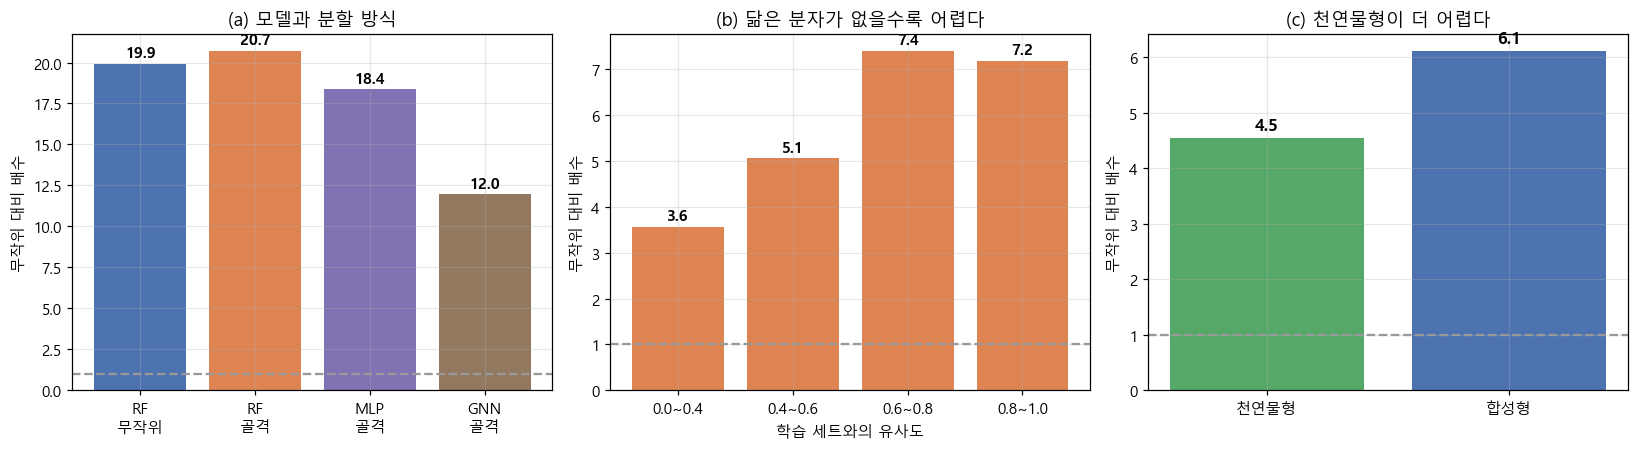


README용 핵심 수치
  무작위 분할              : 19.9배
  골격 분할                : 20.7배
  유사 분자 없을 때        : 7.1배   ← 실제 기대치
  천연물형 / 합성형        : 4.5배 / 6.1배
  RF / MLP / GNN           : 20.7 / 18.4 / 12.0배


In [17]:
# ==================== 16번 셀 ====================
# 지금까지의 결과를 한 곳에 모읍니다.
# =================================================

print("=" * 66)
print(f"전체 결과 요약 — 상위 {TOP_K}개")
print("=" * 66)

# --- 1) 모델 x 분할 ---
print()
print("[1] 모델과 분할 방식")
print("-" * 66)
print(f"{'모델':<16} {'분할':<10} {'활성':>7} {'무작위':>9} {'배수':>9}")
print("-" * 66)
for key in ["RF_random", "RF_scaffold", "NN_scaffold", "GNN_scaffold"]:
    r = results[key]
    print(f"{r['model']:<16} {r['split']:<10} {r['n_hit']:>7} "
          f"{r['n_rand']:>9.1f} {r['fold']:>8.1f}배")

# --- 2) 유사도 구간별 (랜덤 포레스트) ---
print()
print("[2] 학습 세트와의 유사도에 따른 성능 (랜덤 포레스트)")
print("-" * 66)
print(f"{'유사도 구간':<14} {'분자수':>8} {'배수(상위10%)':>16}")
print("-" * 66)
bin_folds = []
for low, high in [(0.0, 0.4), (0.4, 0.6), (0.6, 0.8), (0.8, 1.01)]:
    mask = (sim_scaffold >= low) & (sim_scaffold < high)
    if mask.sum() < 50:
        continue
    y_b, p_b = y_test_scaffold[mask], prob_rf_scaffold[mask]
    k = max(10, int(mask.sum() * 0.1))
    hit = int(y_b[np.argsort(p_b)[::-1][:k]].sum())
    fold = hit / (k * y_b.mean())
    bin_folds.append((f"{low:.1f}~{high:.1f}", fold))
    print(f"{low:.1f} ~ {high:.1f}      {int(mask.sum()):>8,} {fold:>15.1f}배")

# --- 3) 천연물형 vs 합성형 ---
print()
print("[3] 천연물형 vs 합성형")
print("-" * 66)
print(f"{'':<12} {'분자수':>8} {'활성률':>9} {'학습유사도':>12} {'배수':>9}")
print("-" * 66)
np_folds = []
for label, mask in [("천연물형", is_np), ("합성형", ~is_np)]:
    y_g, p_g, s_g = y_test_scaffold[mask], prob_rf_scaffold[mask], sim_scaffold[mask]
    k = int(mask.sum() * 0.1)
    hit = int(y_g[np.argsort(p_g)[::-1][:k]].sum())
    fold = hit / (k * y_g.mean())
    np_folds.append((label, fold))
    print(f"{label:<12} {int(mask.sum()):>8,} {y_g.mean()*100:>8.2f}% "
          f"{s_g.mean():>12.3f} {fold:>8.1f}배")


# --- 4) 최종 그림 3장 ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# (a) 모델 비교
ax = axes[0]
keys  = ["RF_random", "RF_scaffold", "NN_scaffold", "GNN_scaffold"]
names = ["RF\n무작위", "RF\n골격", "MLP\n골격", "GNN\n골격"]
vals  = [results[k]["fold"] for k in keys]
bars = ax.bar(names, vals, color=["#4C72B0", "#DD8452", "#8172B3", "#937860"])
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.4, f"{v:.1f}",
            ha="center", fontsize=10, fontweight="bold")
ax.axhline(1.0, color="#999999", ls="--", lw=1.5)
ax.set_ylabel("무작위 대비 배수")
ax.set_title("(a) 모델과 분할 방식")

# (b) 유사도 구간별
ax = axes[1]
bars = ax.bar([b[0] for b in bin_folds], [b[1] for b in bin_folds], color="#DD8452")
for b, (_, v) in zip(bars, bin_folds):
    ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v:.1f}",
            ha="center", fontsize=10, fontweight="bold")
ax.axhline(1.0, color="#999999", ls="--", lw=1.5)
ax.set_xlabel("학습 세트와의 유사도")
ax.set_ylabel("무작위 대비 배수")
ax.set_title("(b) 닮은 분자가 없을수록 어렵다")

# (c) 천연물형 vs 합성형
ax = axes[2]
bars = ax.bar([n[0] for n in np_folds], [n[1] for n in np_folds],
              color=["#55A868", "#4C72B0"])
for b, (_, v) in zip(bars, np_folds):
    ax.text(b.get_x() + b.get_width()/2, v + 0.15, f"{v:.1f}",
            ha="center", fontsize=11, fontweight="bold")
ax.axhline(1.0, color="#999999", ls="--", lw=1.5)
ax.set_ylabel("무작위 대비 배수")
ax.set_title("(c) 천연물형이 더 어렵다")

plt.tight_layout()
plt.show()


# --- 5) README용 핵심 수치 ---
hard = sim_scaffold < 0.4
y_h  = y_test_scaffold[hard]
hit_h = int(y_h[np.argsort(prob_rf_scaffold[hard])[::-1][:100]].sum())

print()
print("=" * 66)
print("README용 핵심 수치")
print("=" * 66)
print(f"  무작위 분할              : {results['RF_random']['fold']:.1f}배")
print(f"  골격 분할                : {results['RF_scaffold']['fold']:.1f}배")
print(f"  유사 분자 없을 때        : {hit_h/(100*y_h.mean()):.1f}배   ← 실제 기대치")
print(f"  천연물형 / 합성형        : {np_folds[0][1]:.1f}배 / {np_folds[1][1]:.1f}배")
print(f"  RF / MLP / GNN           : {results['RF_scaffold']['fold']:.1f} / "
      f"{results['NN_scaffold']['fold']:.1f} / {results['GNN_scaffold']['fold']:.1f}배")

# 정리

## 결과

### 1. 평가 방식에 따라 성능이 3배 달라진다

| 조건 | 배수 |
|---|---|
| 무작위 분할 | 19.9배 |
| 골격 분할 | 20.7배 |
| **유사 분자가 없을 때** | **7.1배** |

골격을 분리해도 성능이 유지된 이유는 **닮은 분자가 9.6% 남아 있었고
모델이 그것을 골랐기 때문**입니다.
모델이 고른 상위 100개의 평균 유사도는 0.726, 전체 평균은 0.470이었습니다.

새로운 골격을 찾는 것이 목적이라면 실제 기대치는 **7배**입니다.
20배만 보고하면 3배 부풀린 셈입니다.

### 2. 천연물이 더 어렵다

| | 활성률 | 학습 유사도 | 배수 |
|---|---|---|---|
| 천연물형 | 3.11% | 0.422 | **4.5배** |
| 합성형 | 3.53% | 0.487 | **6.1배** |

활성률은 비슷한데 성능은 26% 낮습니다.
스크리닝 라이브러리가 합성 화합물 위주라 참고할 예시가 적습니다.
**천연물이 덜 활성인 게 아니라, 모델이 천연물을 덜 찾아냅니다.**

### 3. 이 규모에서는 단순한 모델이 낫다

| | 전체 | 유사도 0.4 미만 |
|---|---|---|
| 랜덤 포레스트 | **20.7배** | **7.1배** |
| MLP | 18.4배 | 2.1배 |
| GNN | 12.0배 | 3.3배 |

활성이 1,161개뿐입니다. 딥러닝이 유리해지려면 더 큰 데이터가 필요합니다.

GNN이 MLP보다 어려운 구간에서 나은 것은
**분자 구조를 직접 넣는 것이 지문보다 유리하다**는 신호입니다.
다만 손실이 1.28 → 1.17로 거의 줄지 않아 학습이 덜 된 상태입니다.

---

## 요점

성능 수치는 **어떻게 평가하느냐에 따라 3배까지 달라집니다.**
두 숫자 모두 틀리지 않았지만, 답하는 질문이 다릅니다.

---

## 한계

- 타깃 하나(HIV)의 결과입니다.
- 하이퍼파라미터는 표준값을 그대로 썼고 튜닝하지 않았습니다.
  검증 세트를 보며 조정하면 이 프로젝트가 지적하는 문제를 스스로 범합니다.
- GNN은 학습이 충분히 수렴하지 않았습니다.
- NP-likeness는 천연물 여부의 확정이 아니라 점수입니다.

## 다음에 해볼 것

- 다른 표적에서 같은 경향이 나오는지 확인
- GNN 학습 조건을 늘려 수렴시킨 뒤 재비교
- COCONUT, NPAtlas와 대조해 천연물 판정 정확도 개선
- 천연물만 따로 학습시킨 모델이 천연물 발굴에서 더 나은지 확인